
Running Variogram FD in FAST mode
decimate=2, max_samples=60000, lags=[1, 2, 4, 8, 16, 32, 64]
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Variogram Fractal Dimensions:
   channel  variogram_fd  hurst_exponent  scaling_slope  fit_intercept  \
0      CP2      2.019304       -0.019304      -0.038608      -1.891368   
1      CP1      2.018425       -0.018425      -0.036849      -2.405716   
2       Cz      2.016165       -0.016165      -0.032331      -1.007621   
3       C4      2.013092       -0.013092      -0.026184      -2.749717   
4       Pz      2.012836       -0.012836      -0.025673      -0.679829   
5       P4      2.012450       -0.012450      -0.024900      -0.895373   
6       C3      2.011951       -0.011951      -0.023902      -1.090645   
7      FC1      2.009975       -0.009975      -0.01994

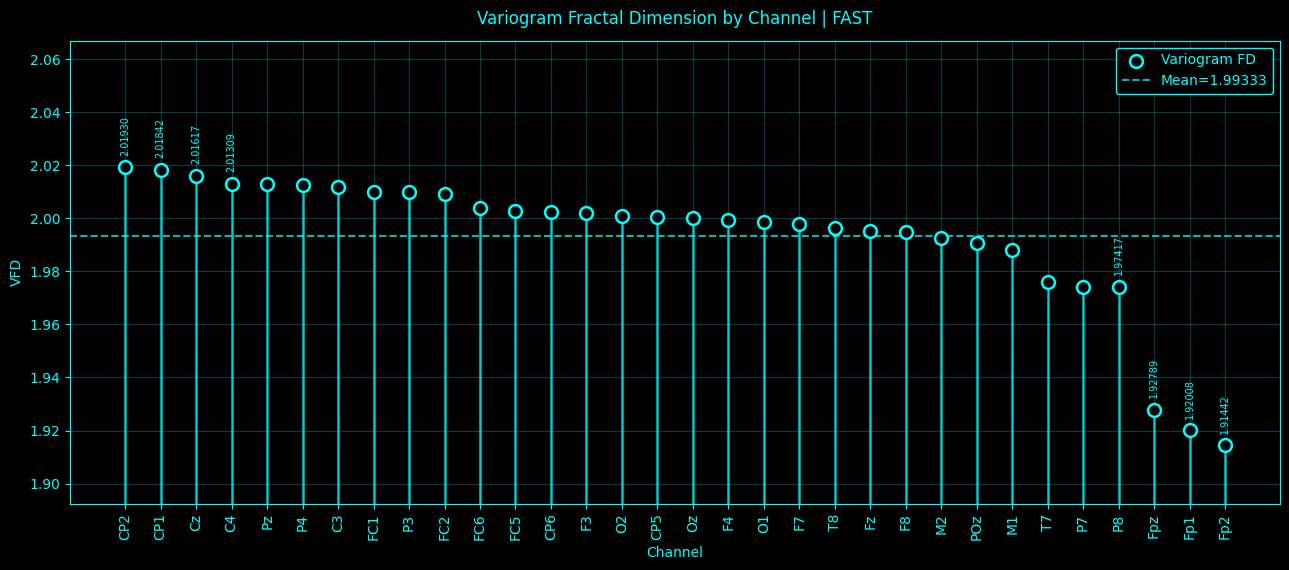

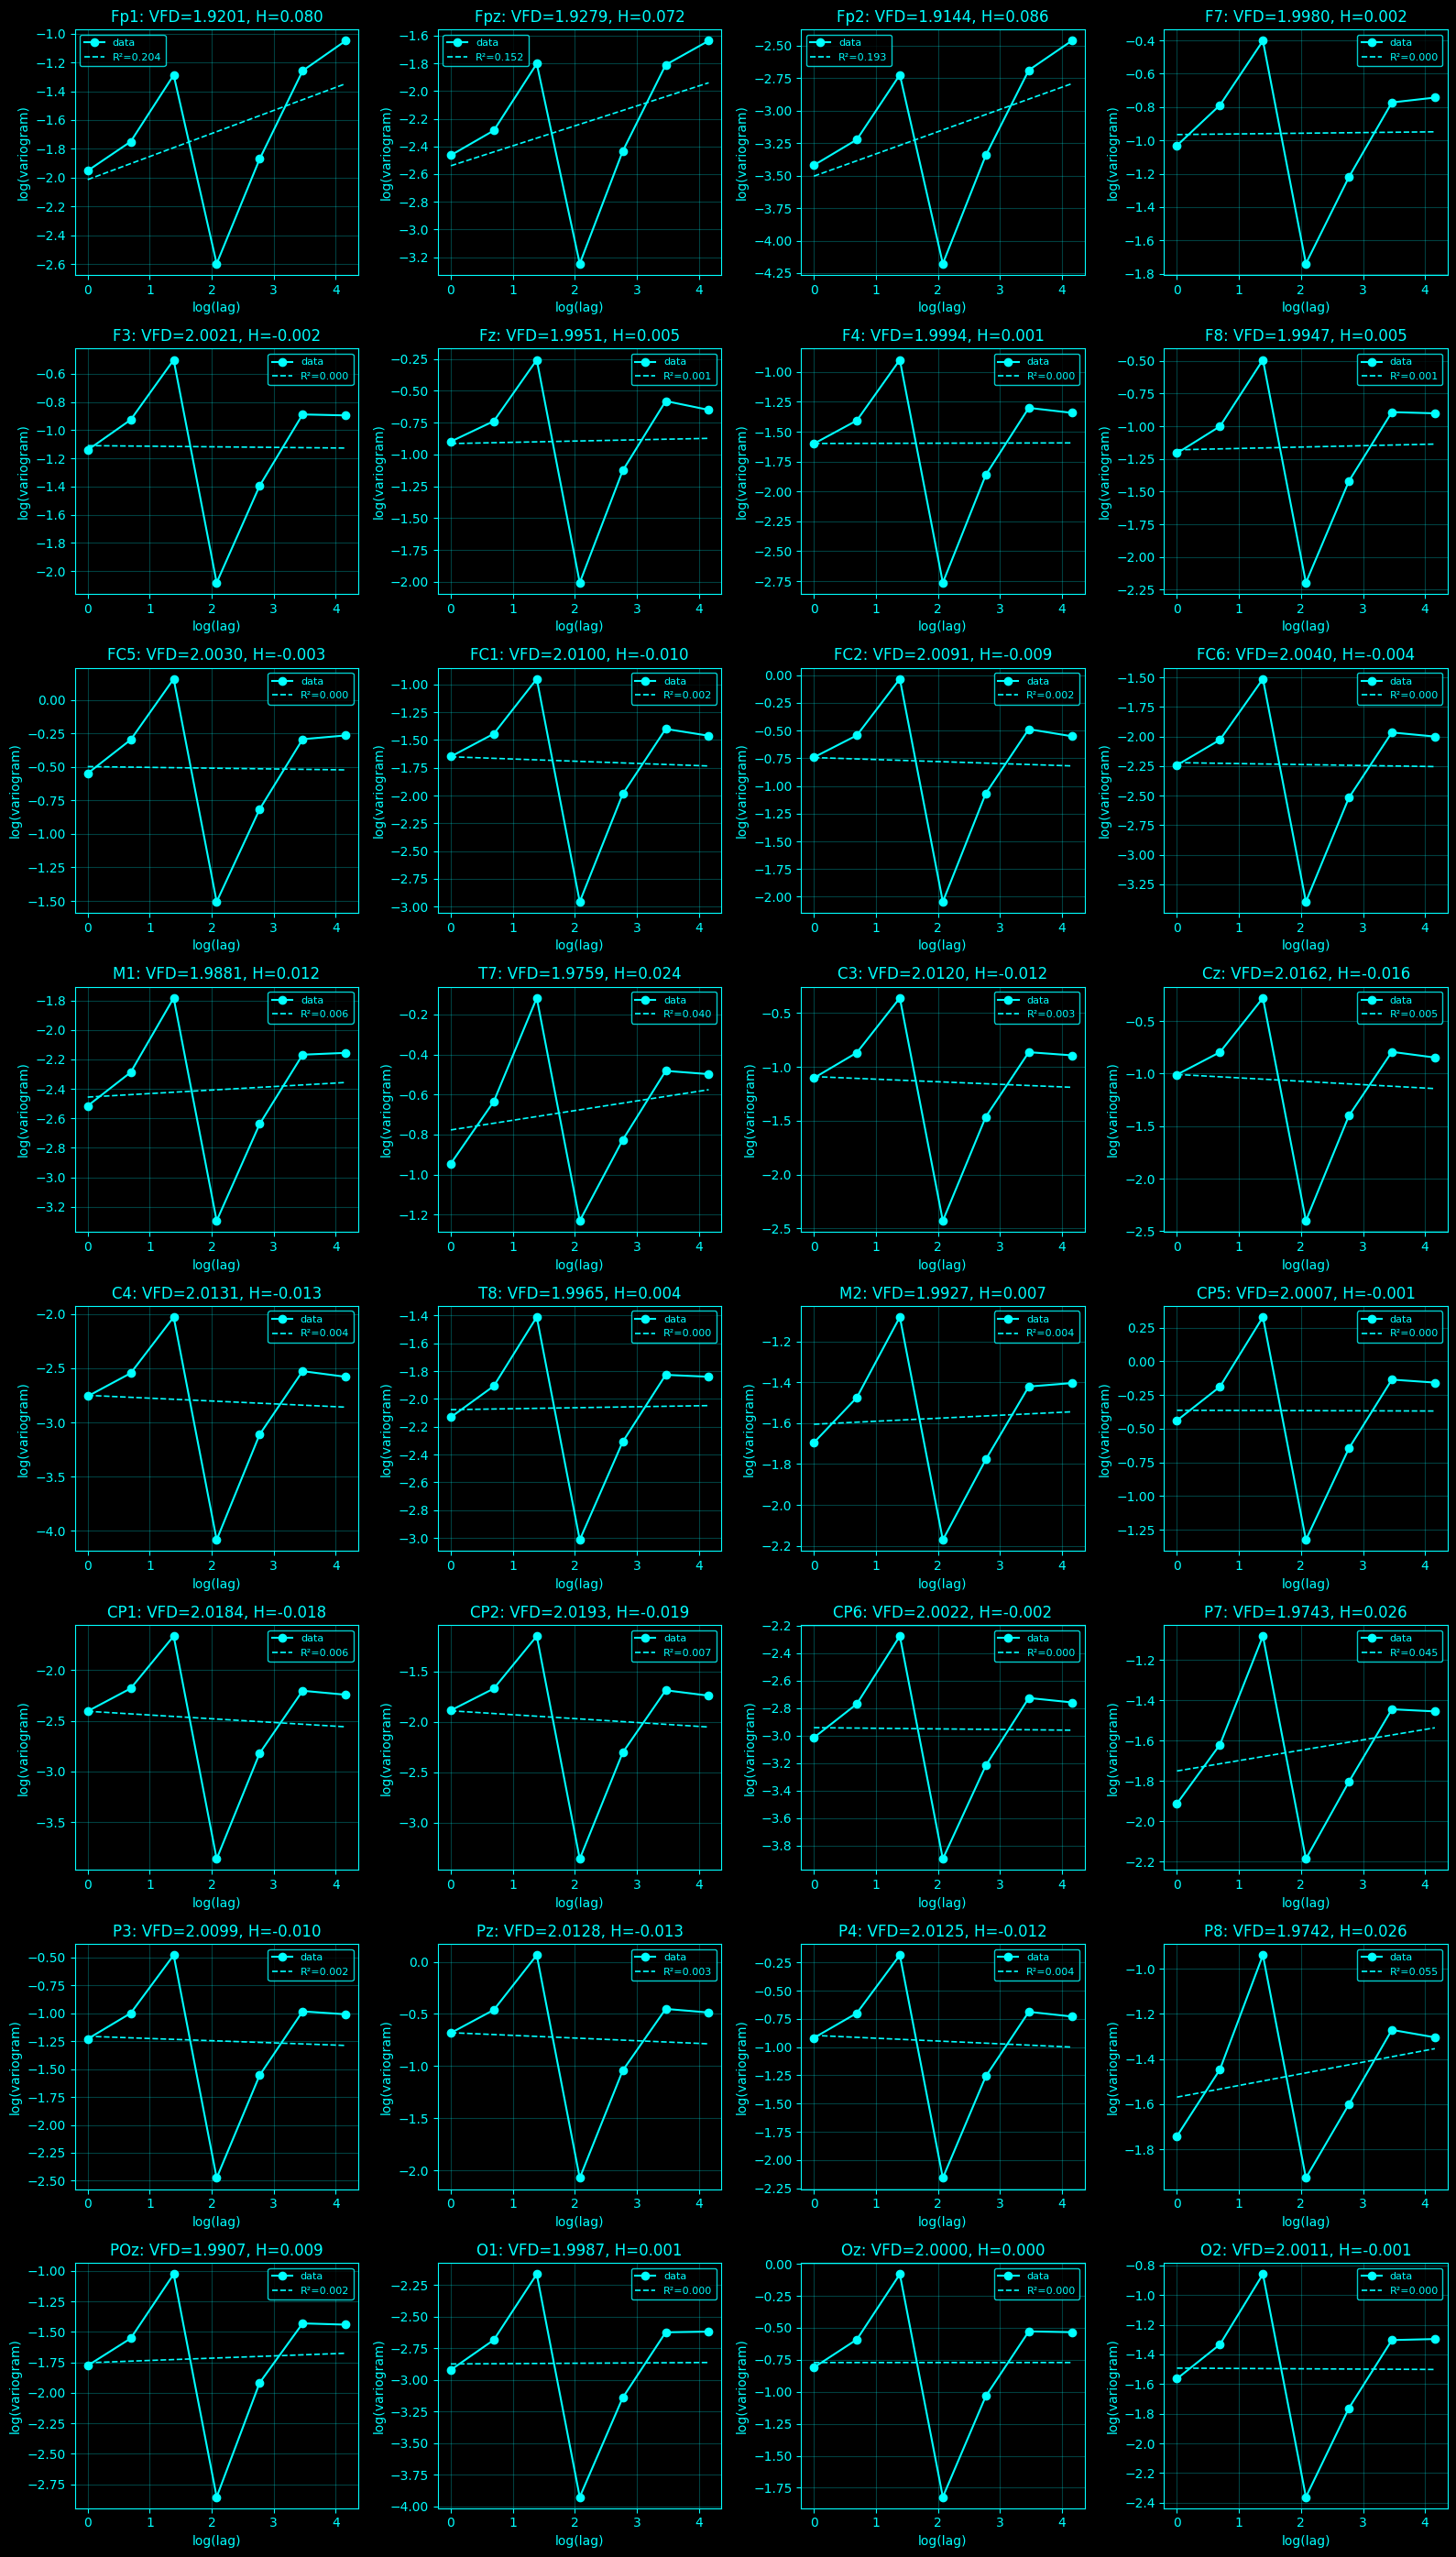

All-channel Variogram fit plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/all_channels_variogram_loglog_fits.png


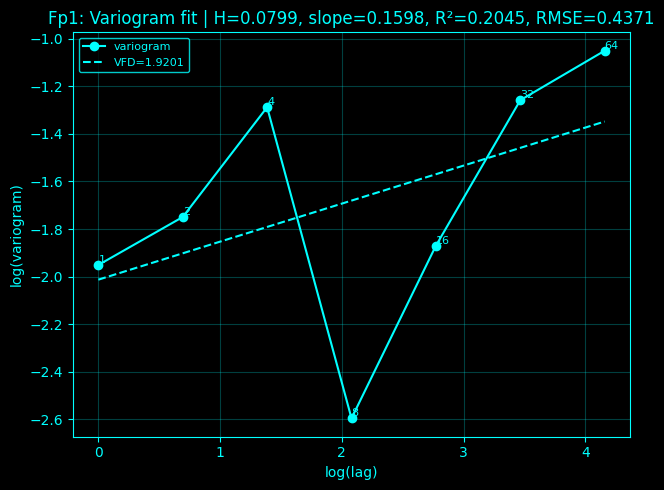

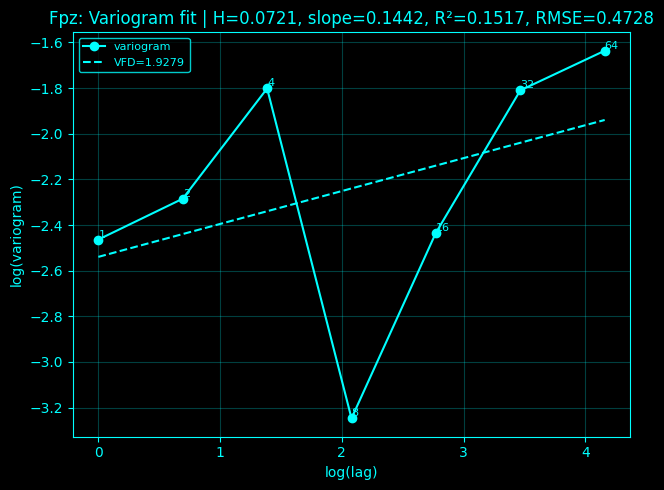

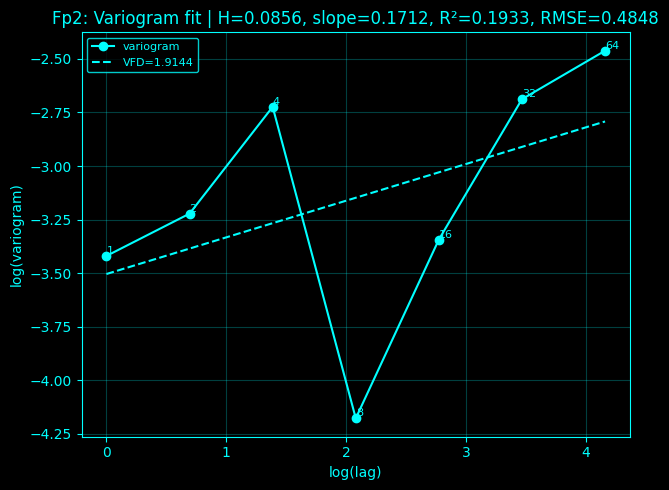

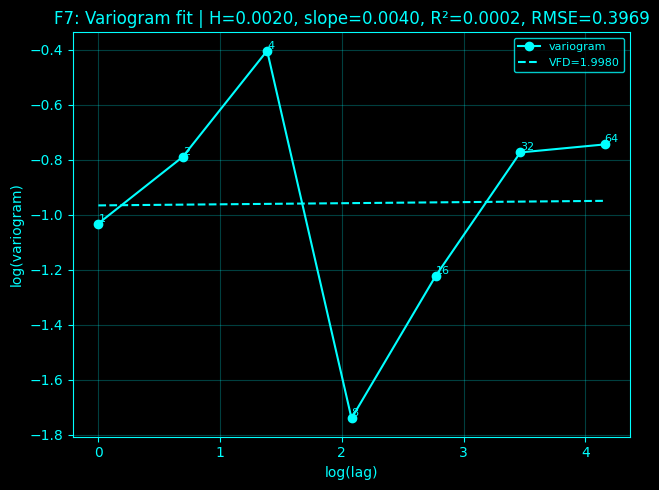

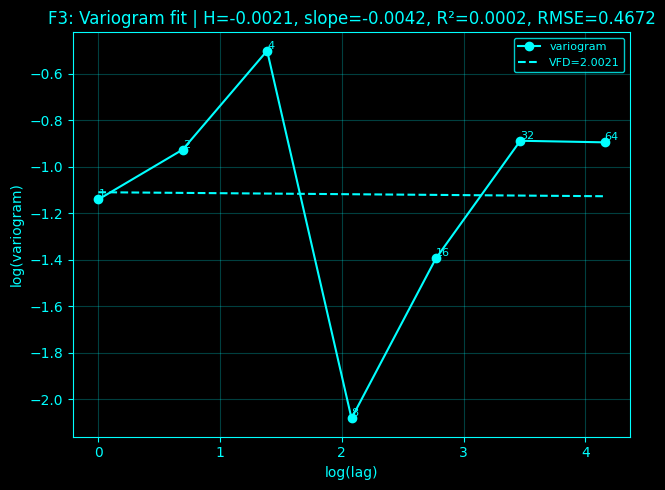

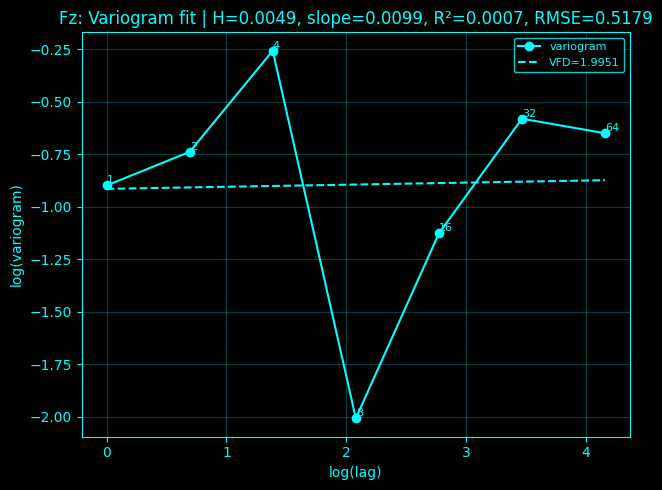

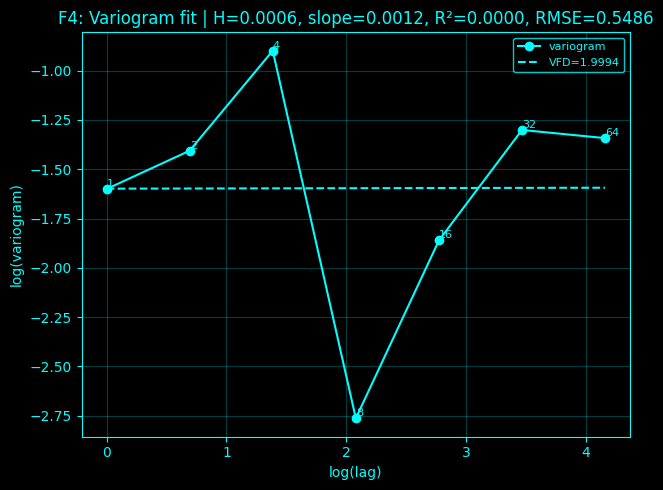

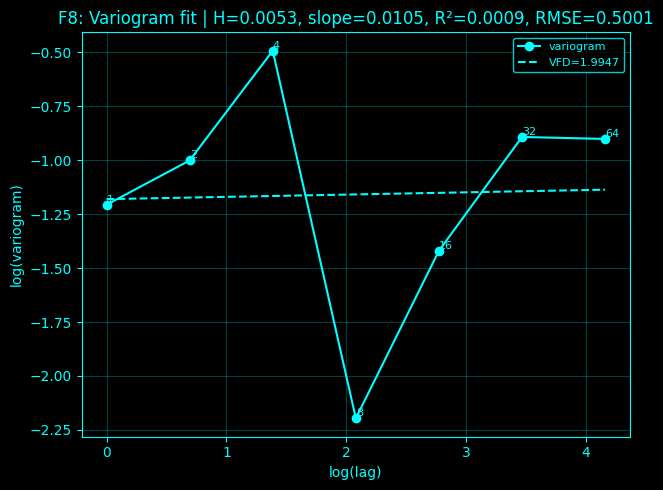

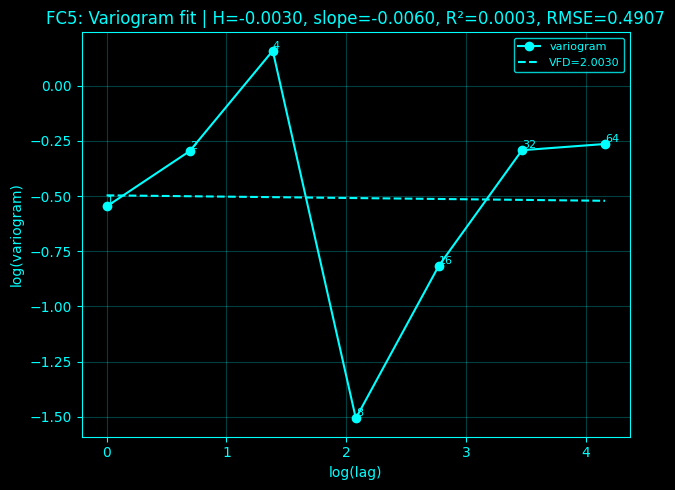

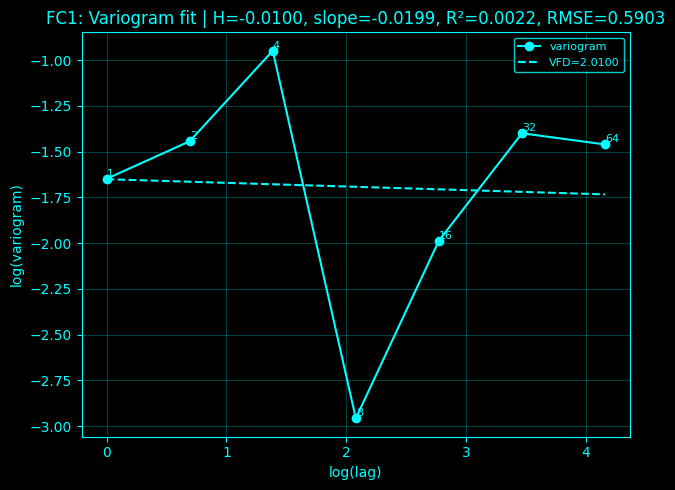

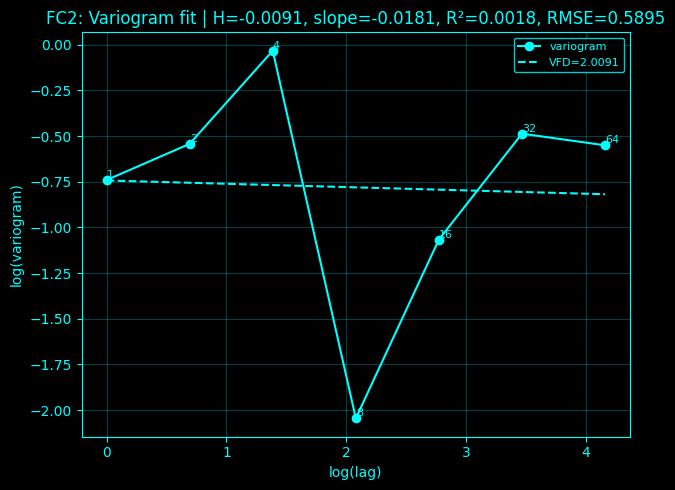

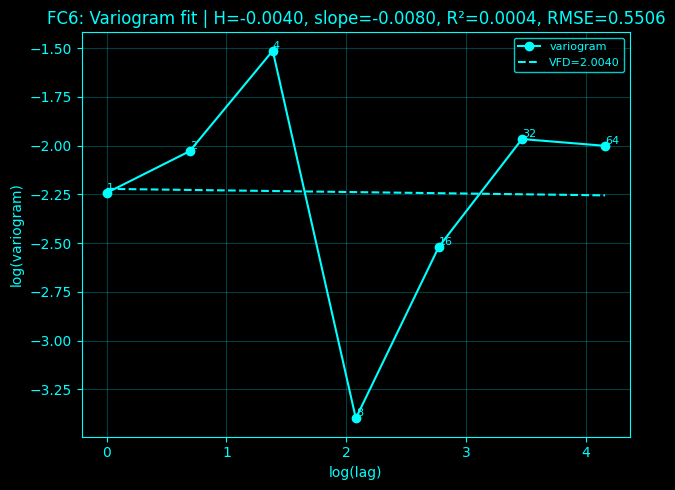

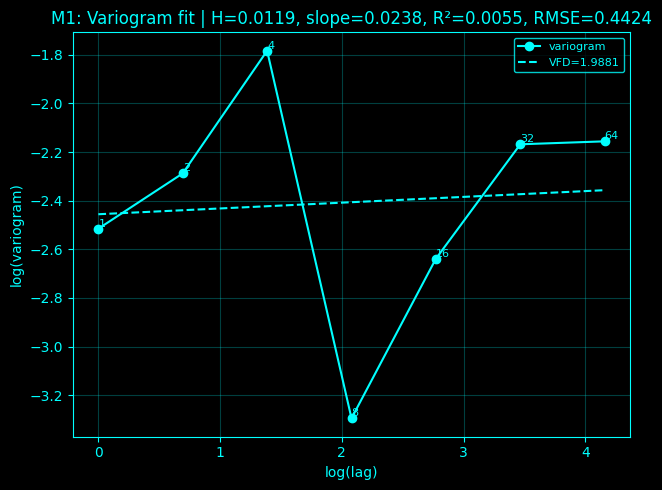

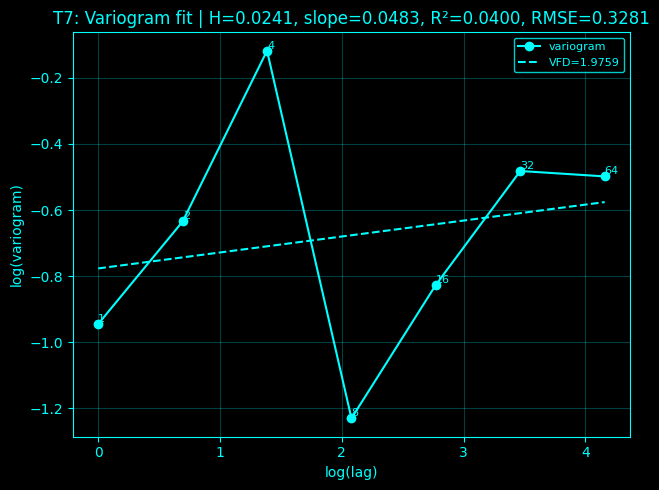

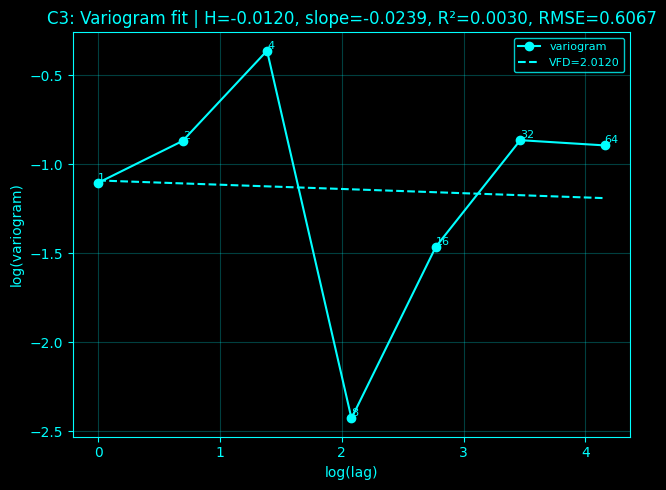

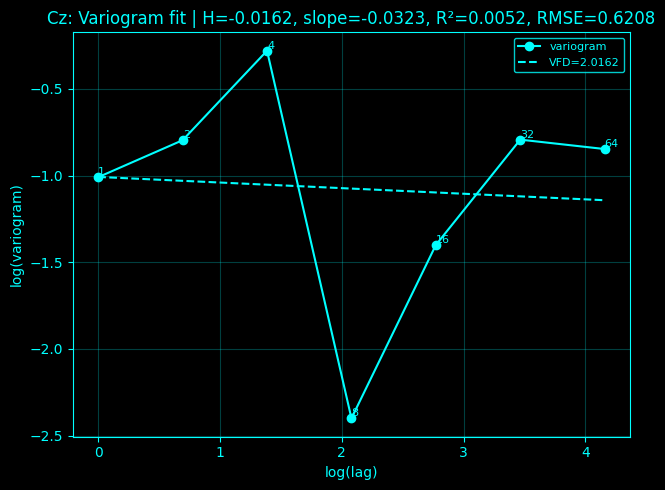

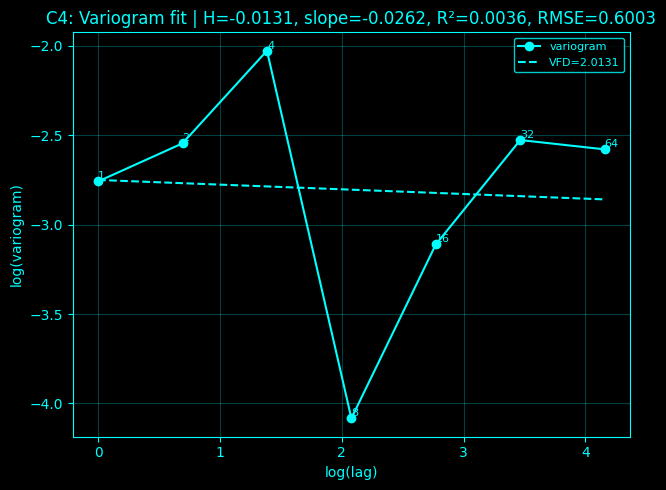

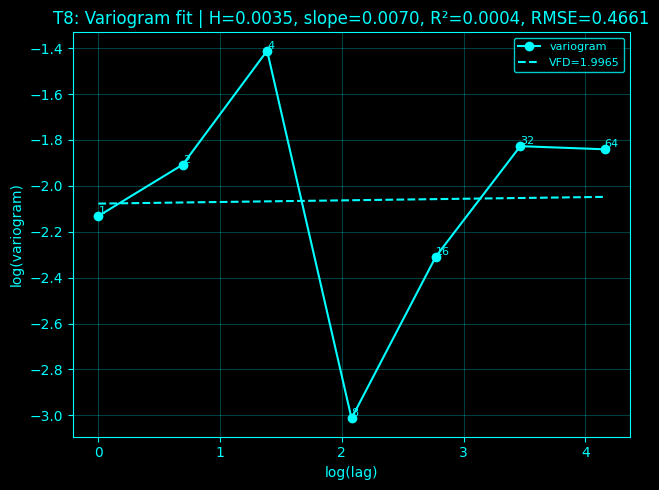

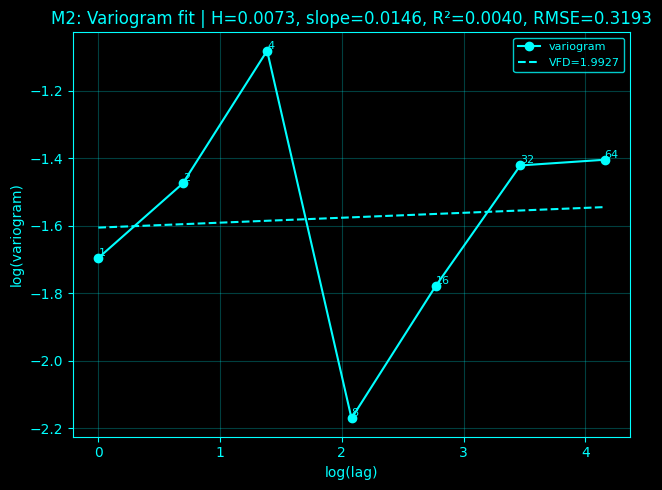

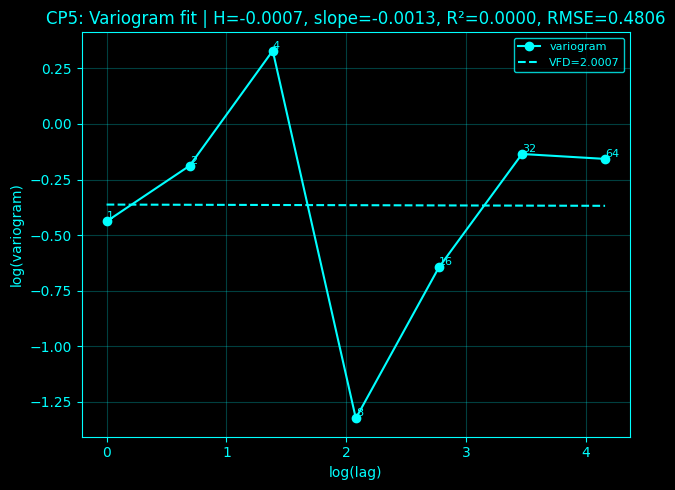

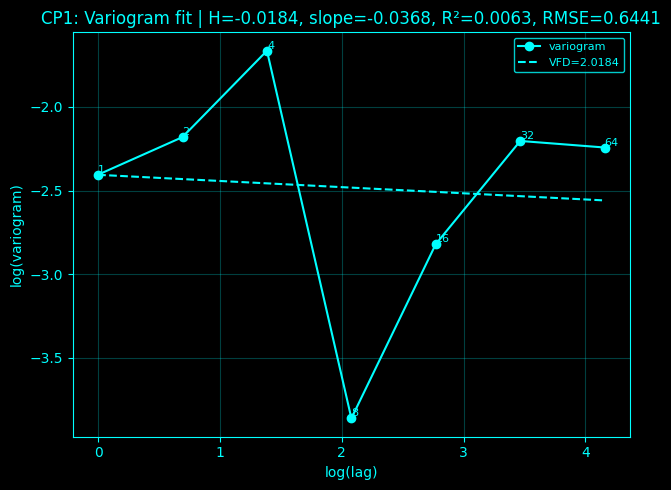

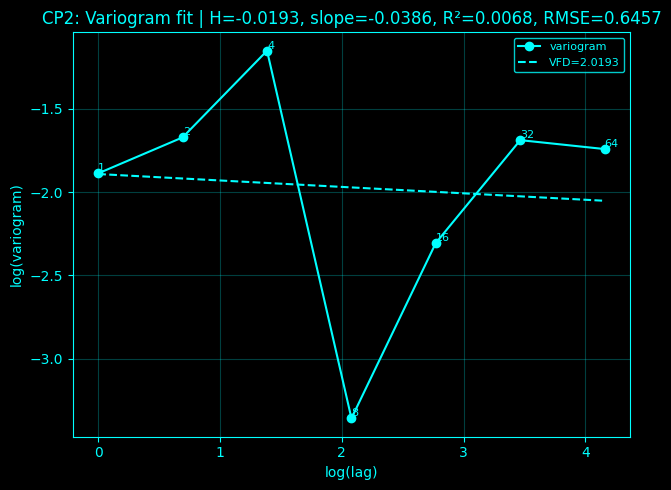

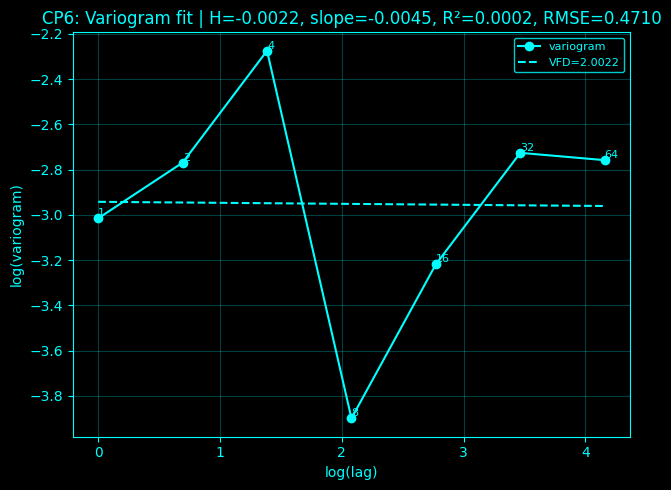

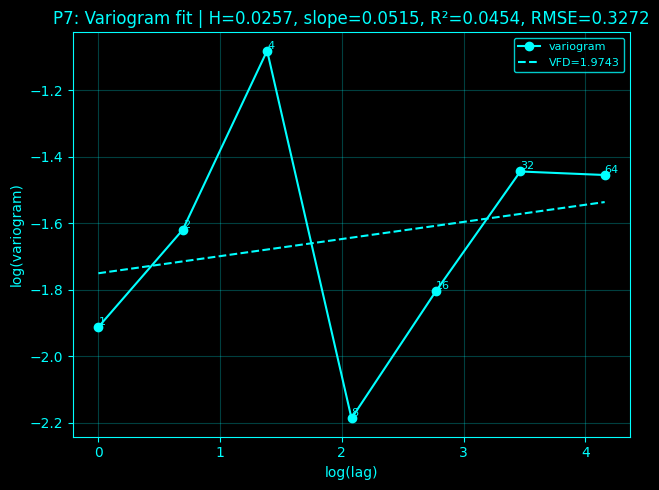

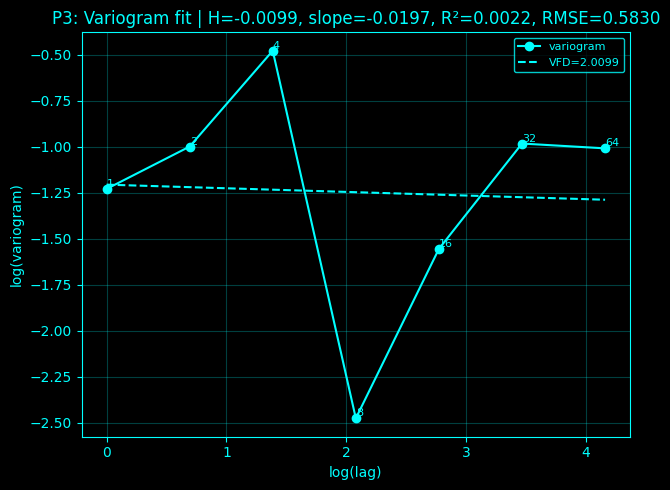

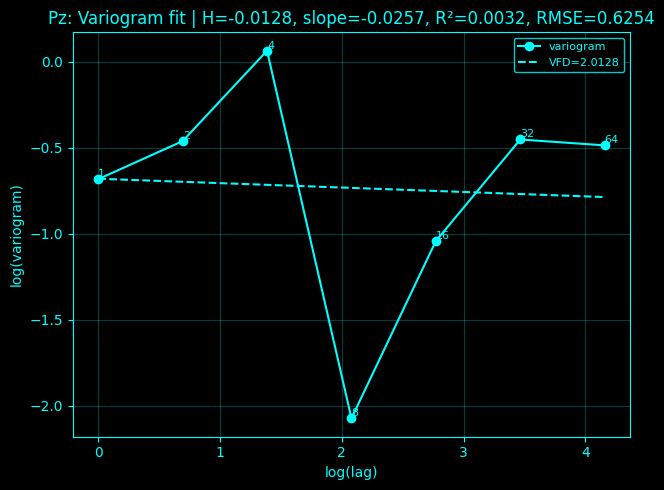

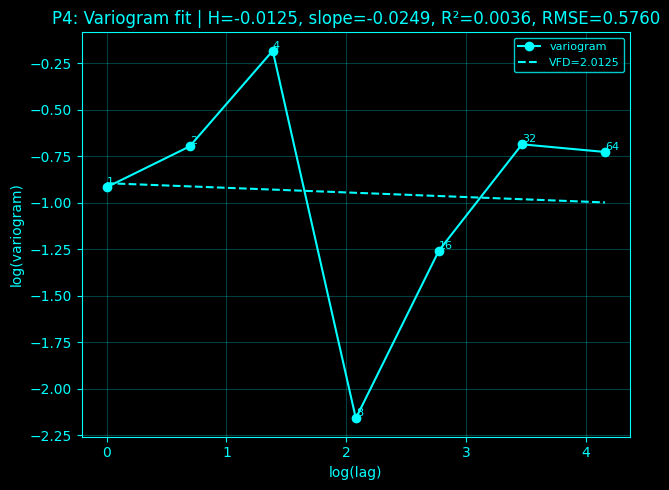

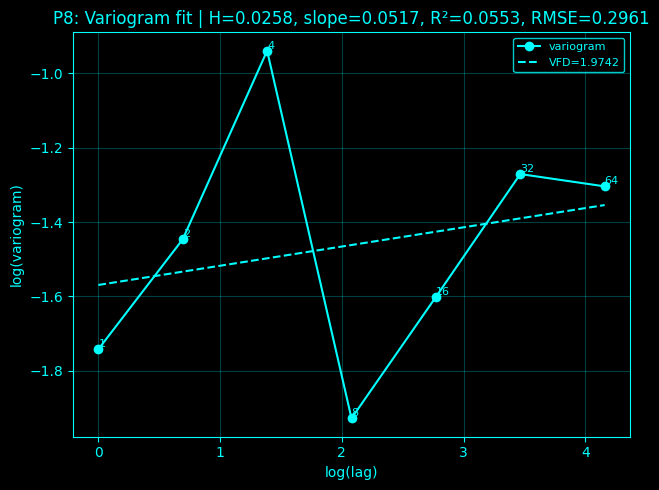

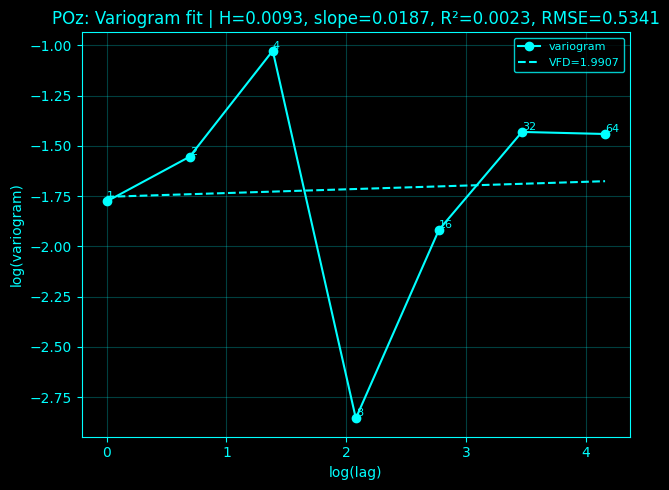

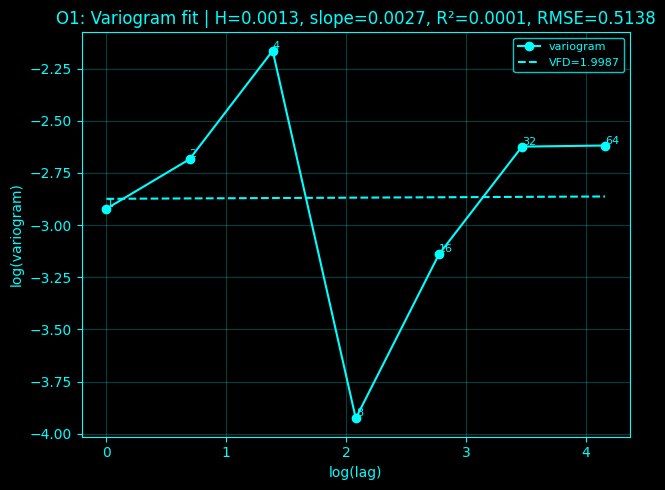

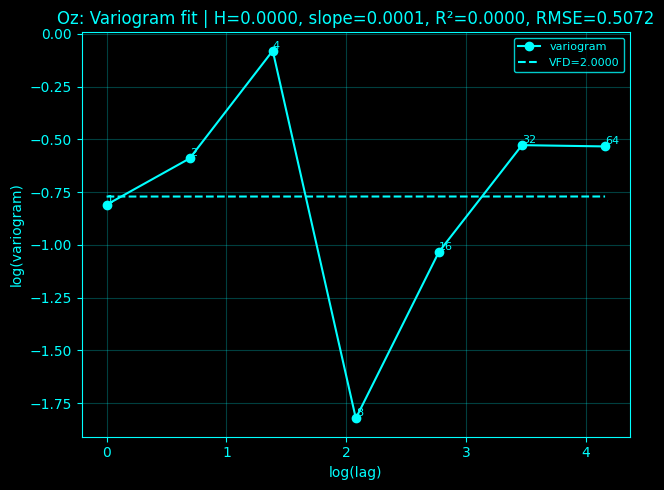

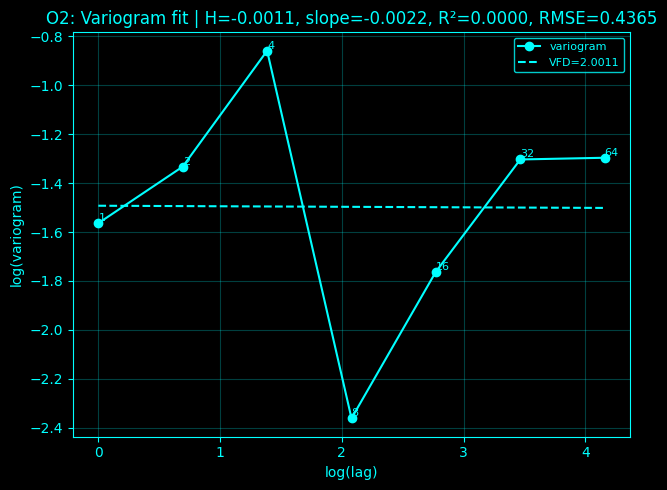

Per-channel Variogram diagnostic plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/per_channel_variogram_diagnostics


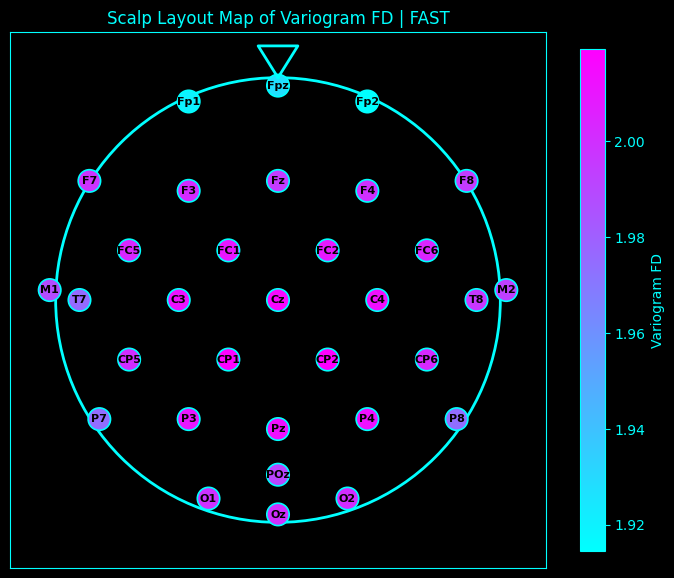

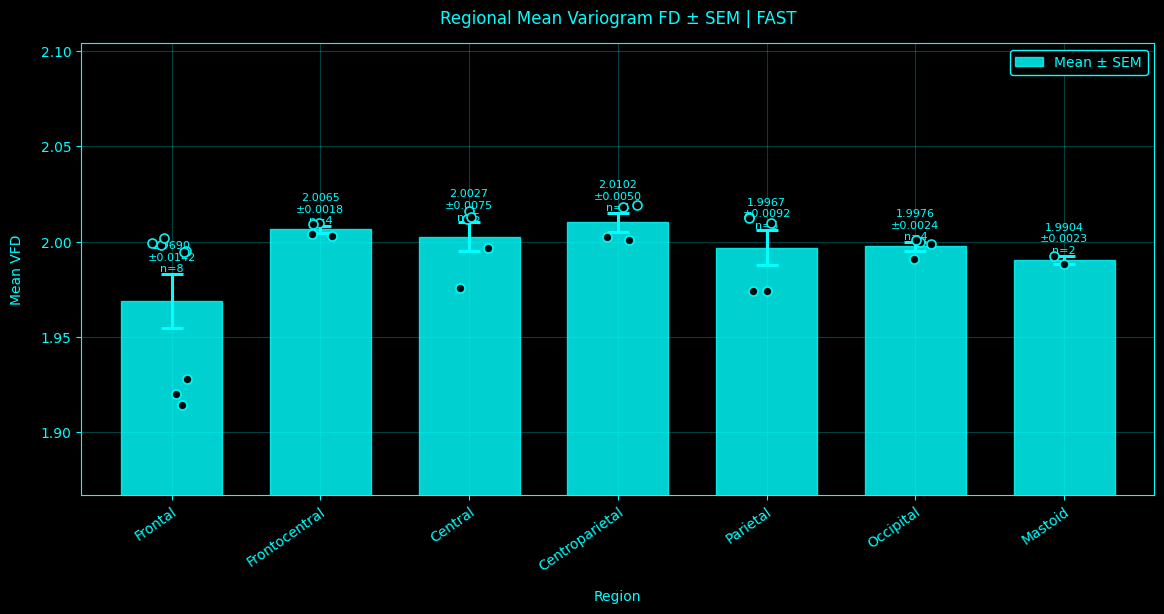

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/regional_variogram_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/regional_variogram_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/regional_variogram_fd_channel_points.csv


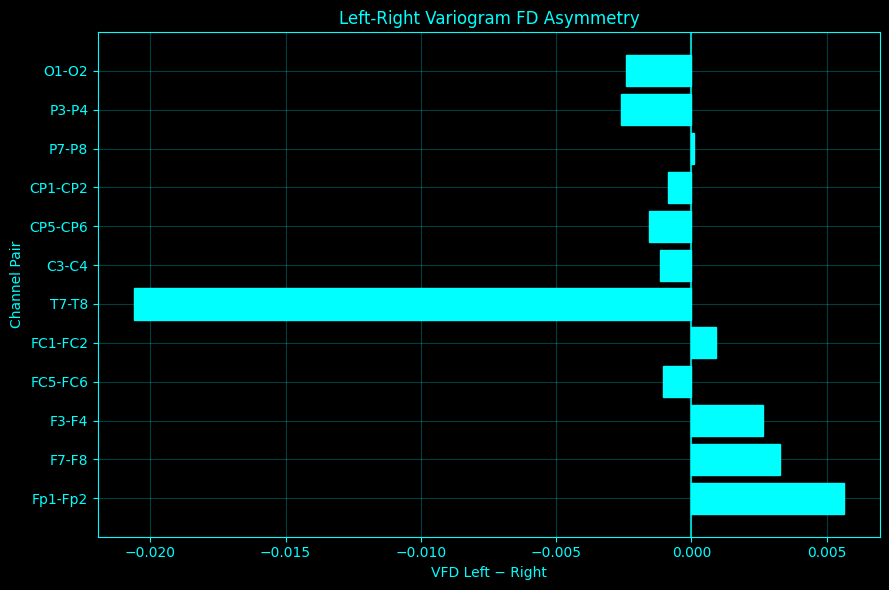

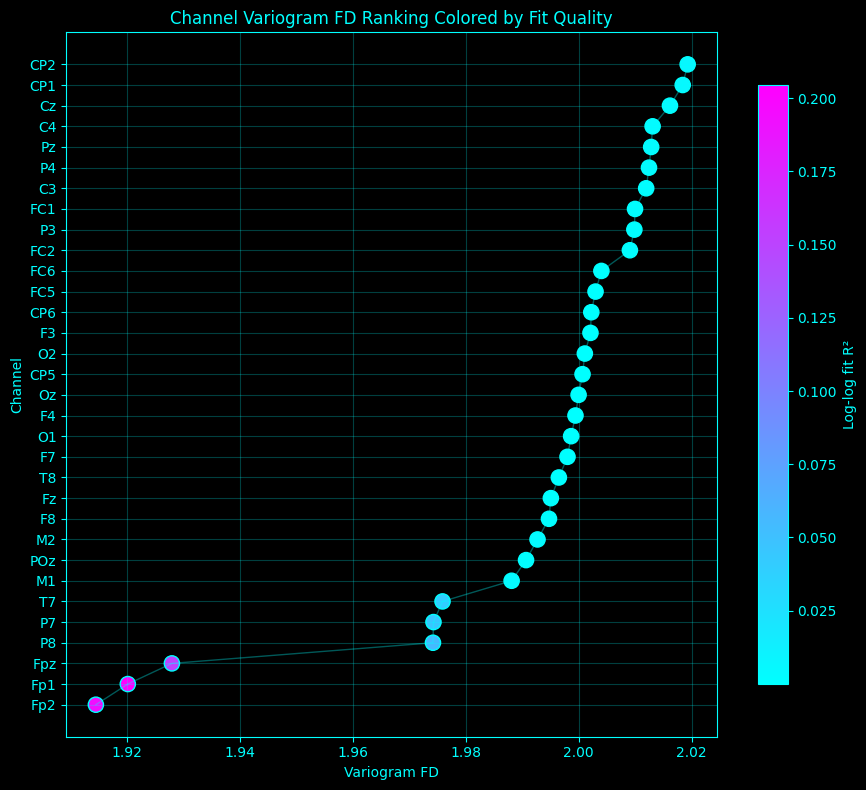

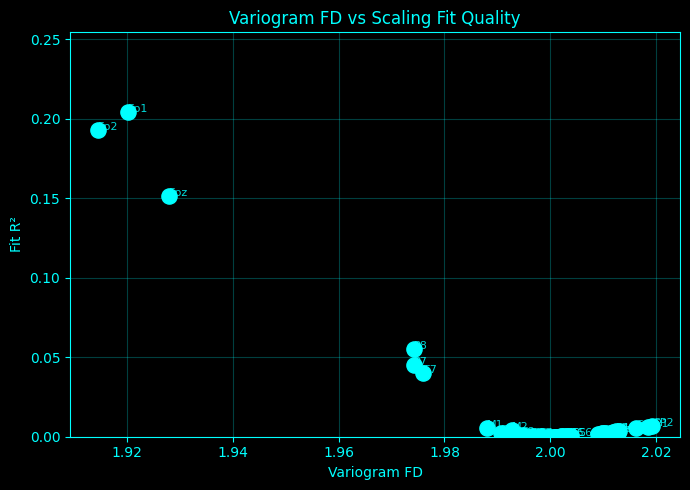

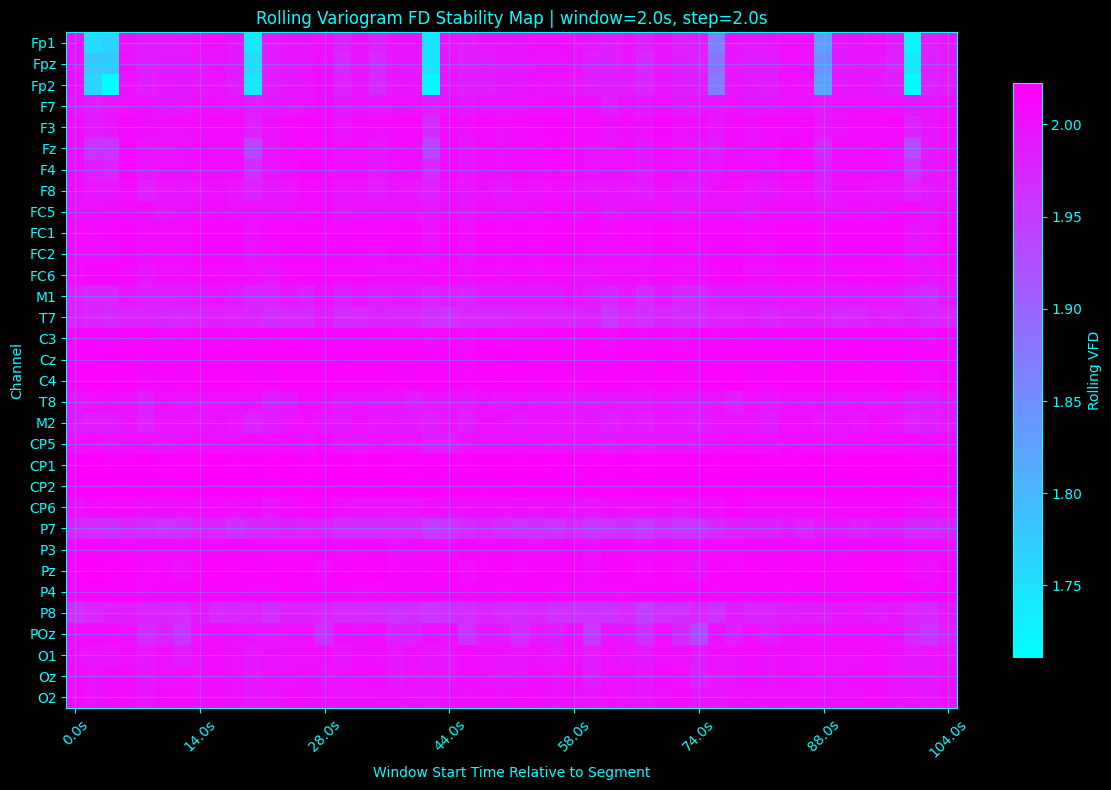

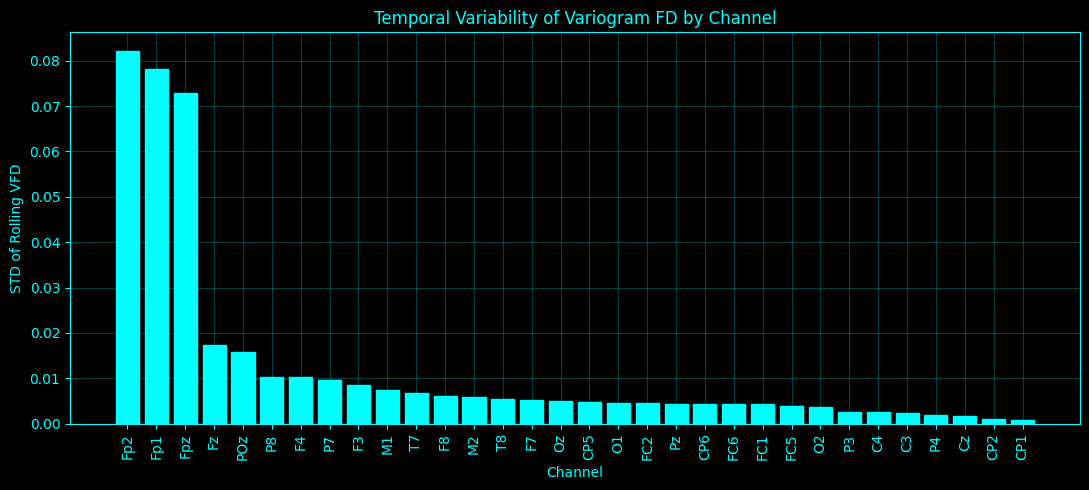

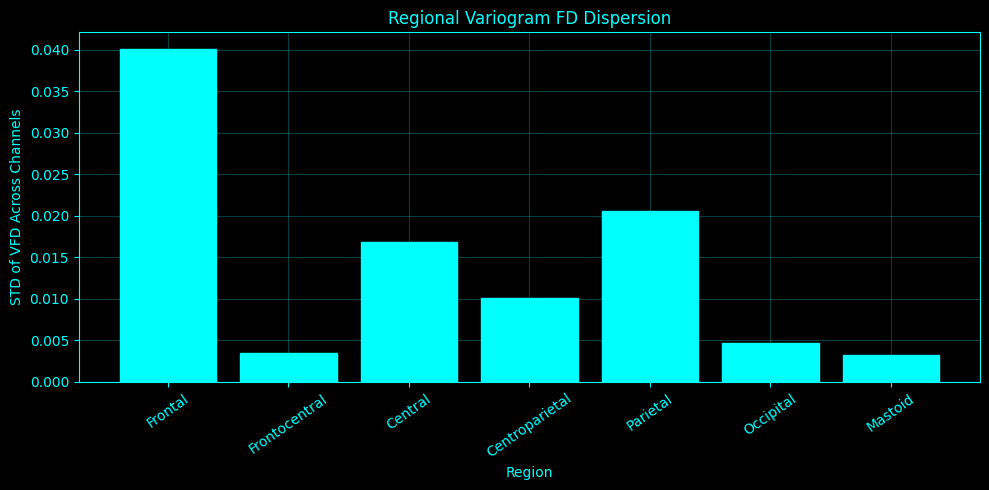

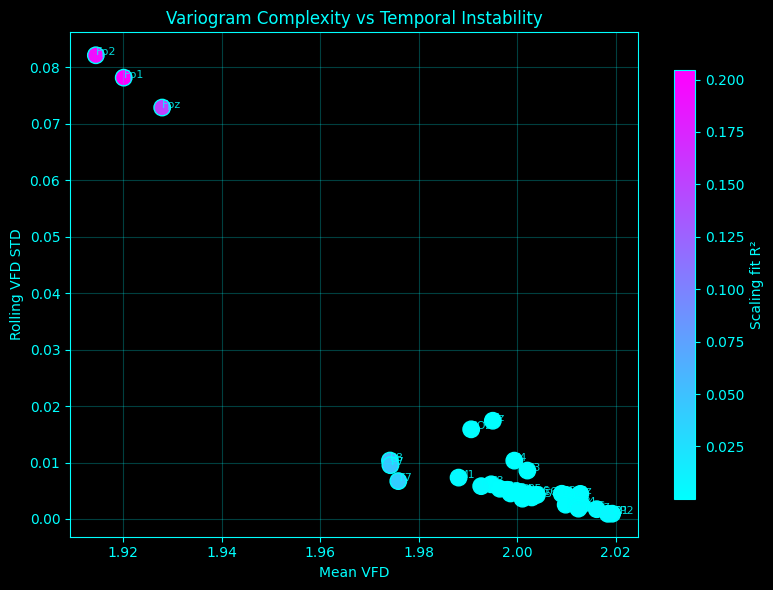


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/regional_variogram_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/left_right_variogram_fd_asymmetry.csv
Rolling VFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/rolling_variogram_fd_by_channel.csv
Rolling fit R² CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/rolling_variogram_fit_r2_by_channel.csv
Rolling Hurst CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/rolling_variogram_hurst_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_variogram/expert_plots_fast/rolling_v

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_variogram")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "decimate": 1,
        "max_samples": None,
        "lags": [1, 2, 4, 8, 16, 32, 64, 128],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 100,
        "expert_plots": True,
    },
    "fast": {
        "decimate": 2,
        "max_samples": 60000,
        "lags": [1, 2, 4, 8, 16, 32, 64],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 50,
        "expert_plots": True,
    },
    "ultrafast": {
        "decimate": 5,
        "max_samples": 20000,
        "lags": [1, 2, 4, 8, 16, 32],
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 20,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]
variogram_lags = mode_cfg["lags"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Variogram FD in {MODE.upper()} mode")
print(f"decimate={decimate}, max_samples={max_samples}, lags={variogram_lags}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# VARIOGRAM FRACTAL DIMENSION
# -------------------------------------------------------
def variogram_fd(x, lags=None):
    """
    Compute Variogram Fractal Dimension for a 1D time series.

    For a self-affine signal graph:

        gamma(lag) = 0.5 * mean((x[t + lag] - x[t])^2)

    and:

        gamma(lag) ~ lag^(2H)

    Therefore:

        slope = d log(gamma) / d log(lag) = 2H
        H = slope / 2
        D = 2 - H

    so:

        VFD = 2 - slope / 2

    This is a fractal roughness / self-affine scaling analysis for the signal graph.
    It is not a phase-space or dynamical-systems method.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if lags is None:
        lags = [1, 2, 4, 8, 16, 32, 64]

    if N < 8:
        return np.nan, None, None, {
            "hurst_exponent": np.nan,
            "scaling_slope": np.nan,
            "fit_intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "n_valid_scales": 0,
            "mean_variogram": np.nan,
            "variogram_range": np.nan,
        }

    valid_lags = []
    lag_seconds = []
    variograms = []
    mean_abs_increments = []
    mean_squared_increments = []

    for lag in lags:
        lag = int(lag)

        if lag < 1 or lag >= N:
            continue

        diffs = x[lag:] - x[:-lag]

        if len(diffs) < 3:
            continue

        msd = np.mean(diffs ** 2)
        gamma = 0.5 * msd
        mean_abs = np.mean(np.abs(diffs))

        if np.isfinite(gamma) and gamma > 0:
            valid_lags.append(lag)
            lag_seconds.append(lag)
            variograms.append(gamma)
            mean_abs_increments.append(mean_abs)
            mean_squared_increments.append(msd)

    valid_lags = np.asarray(valid_lags, dtype=int)
    lag_seconds = np.asarray(lag_seconds, dtype=float)
    variograms = np.asarray(variograms, dtype=float)
    mean_abs_increments = np.asarray(mean_abs_increments, dtype=float)
    mean_squared_increments = np.asarray(mean_squared_increments, dtype=float)

    mask = (
        np.isfinite(valid_lags)
        & np.isfinite(variograms)
        & (valid_lags > 0)
        & (variograms > 0)
    )

    if np.sum(mask) < 2:
        return np.nan, valid_lags, variograms, {
            "hurst_exponent": np.nan,
            "scaling_slope": np.nan,
            "fit_intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "n_valid_scales": int(np.sum(mask)),
            "mean_variogram": np.nanmean(variograms) if len(variograms) else np.nan,
            "variogram_range": (
                np.nanmax(variograms) - np.nanmin(variograms)
                if len(variograms) else np.nan
            ),
            "mean_abs_increments": mean_abs_increments,
            "mean_squared_increments": mean_squared_increments,
        }

    log_lag = np.log(valid_lags[mask].astype(float))
    log_gamma = np.log(variograms[mask])

    slope, intercept = np.polyfit(log_lag, log_gamma, 1)
    pred = slope * log_lag + intercept

    resid = log_gamma - pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((log_gamma - np.mean(log_gamma)) ** 2)

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = np.sqrt(np.mean(resid ** 2))

    hurst = slope / 2.0
    vfd = 2.0 - hurst

    return vfd, valid_lags, variograms, {
        "hurst_exponent": hurst,
        "scaling_slope": slope,
        "fit_intercept": intercept,
        "fit_r2": r2,
        "fit_rmse": rmse,
        "n_valid_scales": int(np.sum(mask)),
        "mean_variogram": np.nanmean(variograms),
        "variogram_range": np.nanmax(variograms) - np.nanmin(variograms),
        "mean_abs_increments": mean_abs_increments,
        "mean_squared_increments": mean_squared_increments,
    }

# -------------------------------------------------------
# RUN VARIOGRAM FD PER CHANNEL
# -------------------------------------------------------
rows = {}
curves = {}
diagnostic_rows = []

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    vfd, lags_used, variograms, diag = variogram_fd(x, lags=variogram_lags)

    rows[ch_name] = {
        "channel": ch_name,
        "variogram_fd": vfd,
        "hurst_exponent": diag["hurst_exponent"],
        "scaling_slope": diag["scaling_slope"],
        "fit_intercept": diag["fit_intercept"],
        "fit_r2": diag["fit_r2"],
        "fit_rmse": diag["fit_rmse"],
        "n_valid_scales": diag["n_valid_scales"],
        "mean_variogram": diag["mean_variogram"],
        "variogram_range": diag["variogram_range"],
    }

    curves[ch_name] = {
        "lags": lags_used,
        "variograms": variograms,
        "mean_abs_increments": diag.get("mean_abs_increments", None),
        "mean_squared_increments": diag.get("mean_squared_increments", None),
    }

    diagnostic_rows.append(rows[ch_name])

results_df = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("variogram_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "variogram_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nVariogram Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# SAVE DIAGNOSTIC TABLE
# -------------------------------------------------------
diagnostics_df = results_df.copy()

diagnostics_csv_path = os.path.join(out_dir, "variogram_fd_diagnostics.csv")
diagnostics_df.to_csv(diagnostics_csv_path, index=False)

print(f"\nDiagnostics CSV: {diagnostics_csv_path}")

# -------------------------------------------------------
# PLOT 1: FIXED VFD BY CHANNEL PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

plot_df = results_df.copy().sort_values("variogram_fd", ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
y = plot_df["variogram_fd"].to_numpy(dtype=float)

finite_y = y[np.isfinite(y)]

if len(finite_y) == 0:
    y_min, y_max, y_range = 0.0, 1.0, 1.0
else:
    y_min = np.nanmin(finite_y)
    y_max = np.nanmax(finite_y)
    y_range = y_max - y_min

if not np.isfinite(y_range) or y_range <= 0:
    y_range = 0.001

pad = max(0.0005, y_range * 0.35)
baseline = y_min - pad * 0.6

ax.vlines(
    x_pos,
    baseline,
    y,
    color=ACCENT,
    linewidth=1.8,
    alpha=0.75
)

ax.scatter(
    x_pos,
    y,
    s=85,
    facecolors=BG,
    edgecolors=ACCENT,
    linewidths=1.8,
    zorder=4,
    label="Variogram FD"
)

mean_vfd = np.nanmean(y)

ax.axhline(
    mean_vfd,
    color=ACCENT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.75,
    label=f"Mean={mean_vfd:.5f}"
)

top_n = min(4, len(plot_df))
label_indices = list(range(top_n)) + list(range(len(plot_df) - top_n, len(plot_df)))

for i in sorted(set(label_indices)):
    if np.isfinite(y[i]):
        ax.text(
            x_pos[i],
            y[i] + pad * 0.12,
            f"{y[i]:.5f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=ACCENT,
            rotation=90
        )

ax.set_ylim(baseline, y_max + pad * 1.3)

ax.set_title(f"Variogram Fractal Dimension by Channel | {MODE.upper()}", pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("VFD")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ax.legend(loc="best", framealpha=1.0)

bar_path = os.path.join(out_dir, "variogram_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ALL-CHANNEL VARIOGRAM LOG-LOG FITS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    d = curves[ch_name]
    lags_used = d["lags"]
    variograms = d["variograms"]

    vfd_val = rows[ch_name]["variogram_fd"]
    hurst = rows[ch_name]["hurst_exponent"]
    slope = rows[ch_name]["scaling_slope"]
    intercept = rows[ch_name]["fit_intercept"]
    r2 = rows[ch_name]["fit_r2"]

    if lags_used is None or variograms is None:
        ax.set_title(f"{ch_name}: no data")
        ax.axis("off")
        continue

    mask = (
        np.isfinite(lags_used)
        & np.isfinite(variograms)
        & (lags_used > 0)
        & (variograms > 0)
    )

    if np.sum(mask) < 2:
        ax.set_title(f"{ch_name}: insufficient data")
        ax.axis("off")
        continue

    log_lag = np.log(lags_used[mask].astype(float))
    log_gamma = np.log(variograms[mask])
    fit_line = slope * log_lag + intercept

    ax.plot(
        log_lag,
        log_gamma,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        linewidth=1.5,
        label="data"
    )

    ax.plot(
        log_lag,
        fit_line,
        color=ACCENT,
        linestyle="--",
        linewidth=1.2,
        label=f"R²={r2:.3f}"
    )

    ax.set_title(f"{ch_name}: VFD={vfd_val:.4f}, H={hurst:.3f}")
    ax.set_xlabel("log(lag)")
    ax.set_ylabel("log(variogram)")
    ax.legend(fontsize=8)

for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_fits_path = os.path.join(out_dir, "all_channels_variogram_loglog_fits.png")
plt.tight_layout()
plt.savefig(all_fits_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Variogram fit plot saved to: {all_fits_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE DIAGNOSTIC PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_variogram_diagnostics")
os.makedirs(per_channel_dir, exist_ok=True)

for ch_name in eeg_channels:
    d = curves[ch_name]
    lags_used = d["lags"]
    variograms = d["variograms"]

    vfd_val = rows[ch_name]["variogram_fd"]
    hurst = rows[ch_name]["hurst_exponent"]
    slope = rows[ch_name]["scaling_slope"]
    intercept = rows[ch_name]["fit_intercept"]
    r2 = rows[ch_name]["fit_r2"]
    rmse = rows[ch_name]["fit_rmse"]

    if lags_used is None or variograms is None:
        continue

    mask = (
        np.isfinite(lags_used)
        & np.isfinite(variograms)
        & (lags_used > 0)
        & (variograms > 0)
    )

    if np.sum(mask) < 2:
        continue

    log_lag = np.log(lags_used[mask].astype(float))
    log_gamma = np.log(variograms[mask])
    fit_line = slope * log_lag + intercept

    fig, ax = plt.subplots(figsize=(6.5, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        log_lag,
        log_gamma,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        label="variogram"
    )

    ax.plot(
        log_lag,
        fit_line,
        color=ACCENT,
        linestyle="--",
        label=f"VFD={vfd_val:.4f}"
    )

    for xd, yd, lag in zip(log_lag, log_gamma, np.asarray(lags_used)[mask]):
        ax.text(
            xd,
            yd,
            f"{lag}",
            fontsize=8,
            color=ACCENT,
            ha="left",
            va="bottom"
        )

    ax.set_title(
        f"{ch_name}: Variogram fit | H={hurst:.4f}, slope={slope:.4f}, "
        f"R²={r2:.4f}, RMSE={rmse:.4f}"
    )

    ax.set_xlabel("log(lag)")
    ax.set_ylabel("log(variogram)")
    ax.legend(fontsize=8)

    diag_path = os.path.join(per_channel_dir, f"{ch_name}_variogram_diagnostic.png")
    plt.tight_layout()
    plt.savefig(diag_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Variogram diagnostic plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "variogram_fd_curves.npz")

save_dict = {
    "channels": np.asarray(eeg_channels),
    "variogram_fd": np.asarray([rows[ch]["variogram_fd"] for ch in eeg_channels], dtype=float),
    "hurst_exponent": np.asarray([rows[ch]["hurst_exponent"] for ch in eeg_channels], dtype=float),
    "scaling_slope": np.asarray([rows[ch]["scaling_slope"] for ch in eeg_channels], dtype=float),
    "fit_r2": np.asarray([rows[ch]["fit_r2"] for ch in eeg_channels], dtype=float),
    "fit_rmse": np.asarray([rows[ch]["fit_rmse"] for ch in eeg_channels], dtype=float),
}

for ch_name, d in curves.items():
    if d["lags"] is not None:
        save_dict[f"{ch_name}_lags"] = d["lags"]
    if d["variograms"] is not None:
        save_dict[f"{ch_name}_variogram"] = d["variograms"]
    if d["mean_abs_increments"] is not None:
        save_dict[f"{ch_name}_mean_abs_increments"] = d["mean_abs_increments"]
    if d["mean_squared_increments"] is not None:
        save_dict[f"{ch_name}_mean_squared_increments"] = d["mean_squared_increments"]

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    vfd_map = dict(zip(results_df["channel"], results_df["variogram_fd"]))
    hurst_map = dict(zip(results_df["channel"], results_df["hurst_exponent"]))
    slope_map = dict(zip(results_df["channel"], results_df["scaling_slope"]))
    r2_map = dict(zip(results_df["channel"], results_df["fit_r2"]))
    variogram_map = dict(zip(results_df["channel"], results_df["mean_variogram"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT VFD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in vfd_map and np.isfinite(vfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(vfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Variogram FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Variogram FD | {MODE.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "variogram_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL VFD SUMMARY
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in vfd_map and np.isfinite(vfd_map[ch]):
                vals_region.append(vfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "vfd": vfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_vfd": np.mean(vals_region),
            "std_vfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_vfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_variogram_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_variogram_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x_region = np.arange(len(region_df))

    ax.bar(
        x_region,
        region_df["mean_vfd"],
        yerr=region_df["sem_vfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "vfd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y_val = row["mean_vfd"]
        sem = row["sem_vfd"]

        ax.text(
            i,
            y_val + sem,
            f"{y_val:.4f}\n±{sem:.4f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["vfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_vfd"].to_numpy(dtype=float) + region_df["sem_vfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_vfd"].to_numpy(dtype=float) - region_df["sem_vfd"].to_numpy(dtype=float)

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.01

    pad = max(0.0025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Variogram FD ± SEM | {MODE.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean VFD", labelpad=12)

    ax.set_xticks(x_region)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_variogram_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in vfd_map and right_ch in vfd_map:
            left_val = vfd_map[left_ch]
            right_val = vfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_vfd": left_val,
                    "right_vfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_variogram_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Variogram FD Asymmetry")
    ax.set_xlabel("VFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_variogram_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: VFD RANKING COLORED BY FIT QUALITY
    # ---------------------------------------------------
    rank_df = diagnostics_df.copy()
    rank_df = rank_df.sort_values("variogram_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["variogram_fd"],
        rank_df["channel"],
        c=rank_df["fit_r2"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["variogram_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Log-log fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel Variogram FD Ranking Colored by Fit Quality")
    ax.set_xlabel("Variogram FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "variogram_fd_ranking_fit_quality.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: VFD VS FIT R²
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["variogram_fd"],
        diagnostics_df["fit_r2"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["variogram_fd"]) and np.isfinite(row["fit_r2"]):
            ax.text(
                row["variogram_fd"],
                row["fit_r2"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Variogram FD vs Scaling Fit Quality")
    ax.set_xlabel("Variogram FD")
    ax.set_ylabel("Fit R²")

    r2_min = np.nanmin(diagnostics_df["fit_r2"])
    r2_max = np.nanmax(diagnostics_df["fit_r2"])

    if np.isfinite(r2_min) and np.isfinite(r2_max):
        ax.set_ylim(
            max(0, r2_min - 0.05),
            min(1.01, r2_max + 0.05)
        )

    quality_path = os.path.join(expert_dir, "variogram_fd_vs_fit_r2.png")
    plt.tight_layout()
    plt.savefig(quality_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(
        rolling_window_samples,
        max(variogram_lags) * 4 + 1
    )
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_vfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_r2 = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_hurst = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            vfd_w, _, _, diag_w = variogram_fd(xw, lags=variogram_lags)
            rolling_vfd[ch_idx, w_idx] = vfd_w
            rolling_r2[ch_idx, w_idx] = diag_w["fit_r2"]
            rolling_hurst[ch_idx, w_idx] = diag_w["hurst_exponent"]

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_vfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_variogram_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    rolling_r2_df = pd.DataFrame(
        rolling_r2,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_r2_csv_path = os.path.join(expert_dir, "rolling_variogram_fit_r2_by_channel.csv")
    rolling_r2_df.to_csv(rolling_r2_csv_path)

    rolling_hurst_df = pd.DataFrame(
        rolling_hurst,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_hurst_csv_path = os.path.join(expert_dir, "rolling_variogram_hurst_by_channel.csv")
    rolling_hurst_df.to_csv(rolling_hurst_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_vfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Variogram FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling VFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_variogram_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_vfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_vfd_std": temporal_var,
        "mean_vfd": [vfd_map[ch] for ch in eeg_channels],
        "hurst_exponent": [hurst_map[ch] for ch in eeg_channels],
        "fit_r2": [r2_map[ch] for ch in eeg_channels],
        "scaling_slope": [slope_map[ch] for ch in eeg_channels],
        "mean_variogram": [variogram_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_vfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_variogram_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_vfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Variogram FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling VFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_variogram_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_vfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional Variogram FD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of VFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_variogram_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        temporal_df["mean_vfd"],
        temporal_df["rolling_vfd_std"],
        c=temporal_df["fit_r2"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in temporal_df.iterrows():
        if np.isfinite(row["mean_vfd"]) and np.isfinite(row["rolling_vfd_std"]):
            ax.text(
                row["mean_vfd"],
                row["rolling_vfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Scaling fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Variogram Complexity vs Temporal Instability")
    ax.set_xlabel("Mean VFD")
    ax.set_ylabel("Rolling VFD STD")

    instability_path = os.path.join(expert_dir, "variogram_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling VFD CSV: {rolling_csv_path}")
    print(f"Rolling fit R² CSV: {rolling_r2_csv_path}")
    print(f"Rolling Hurst CSV: {rolling_hurst_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Diagnostics CSV: {diagnostics_csv_path}")
print(f"Curves NPZ: {npz_path}")


Running Madogram / Robust Variogram FD in FAST mode
decimate=2, max_samples=60000, lags=[1, 2, 4, 8, 16, 32, 64]
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Madogram / Robust Variogram Fractal Dimensions:
   channel  madogram_fd  robust_madogram_fd  madogram_hurst  madogram_slope  \
0       F3     1.996377            1.977946        0.003623        0.003623   
1       F7     1.992642            1.977258        0.007358        0.007358   
2      FC5     1.995637            1.973681        0.004363        0.004363   
3      CP1     2.006052            1.970439       -0.006052       -0.006052   
4       M2     1.986085            1.969530        0.013915        0.013915   
5       C3     1.999405            1.966916        0.000595        0.000595   
6      CP2     2.006609            1.964227       -0.0066

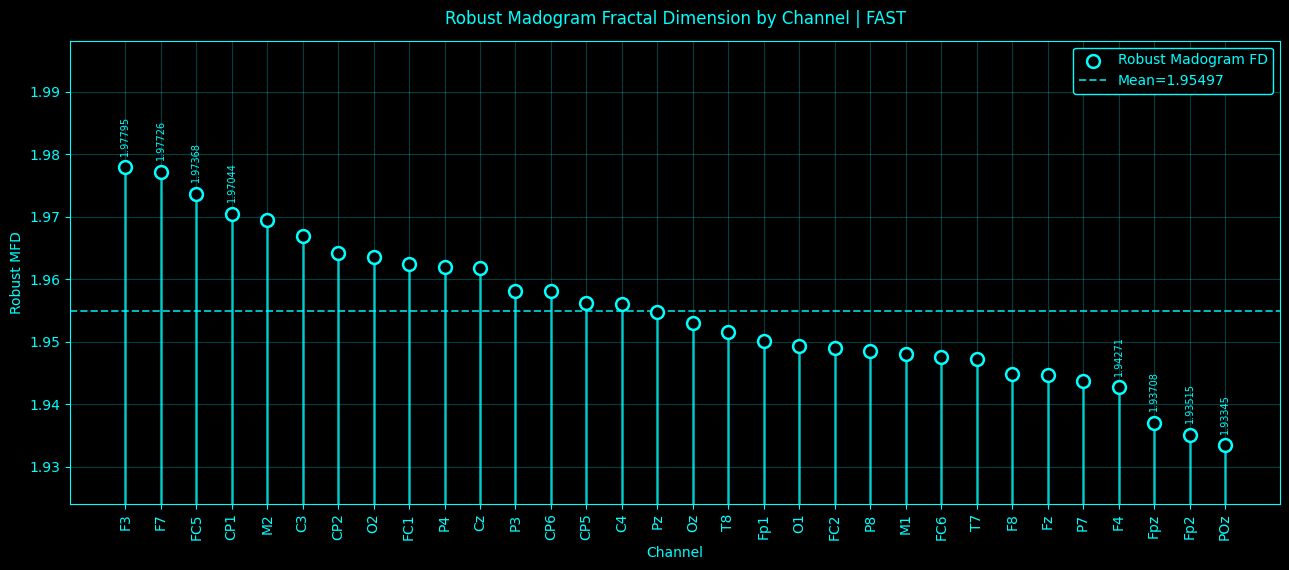

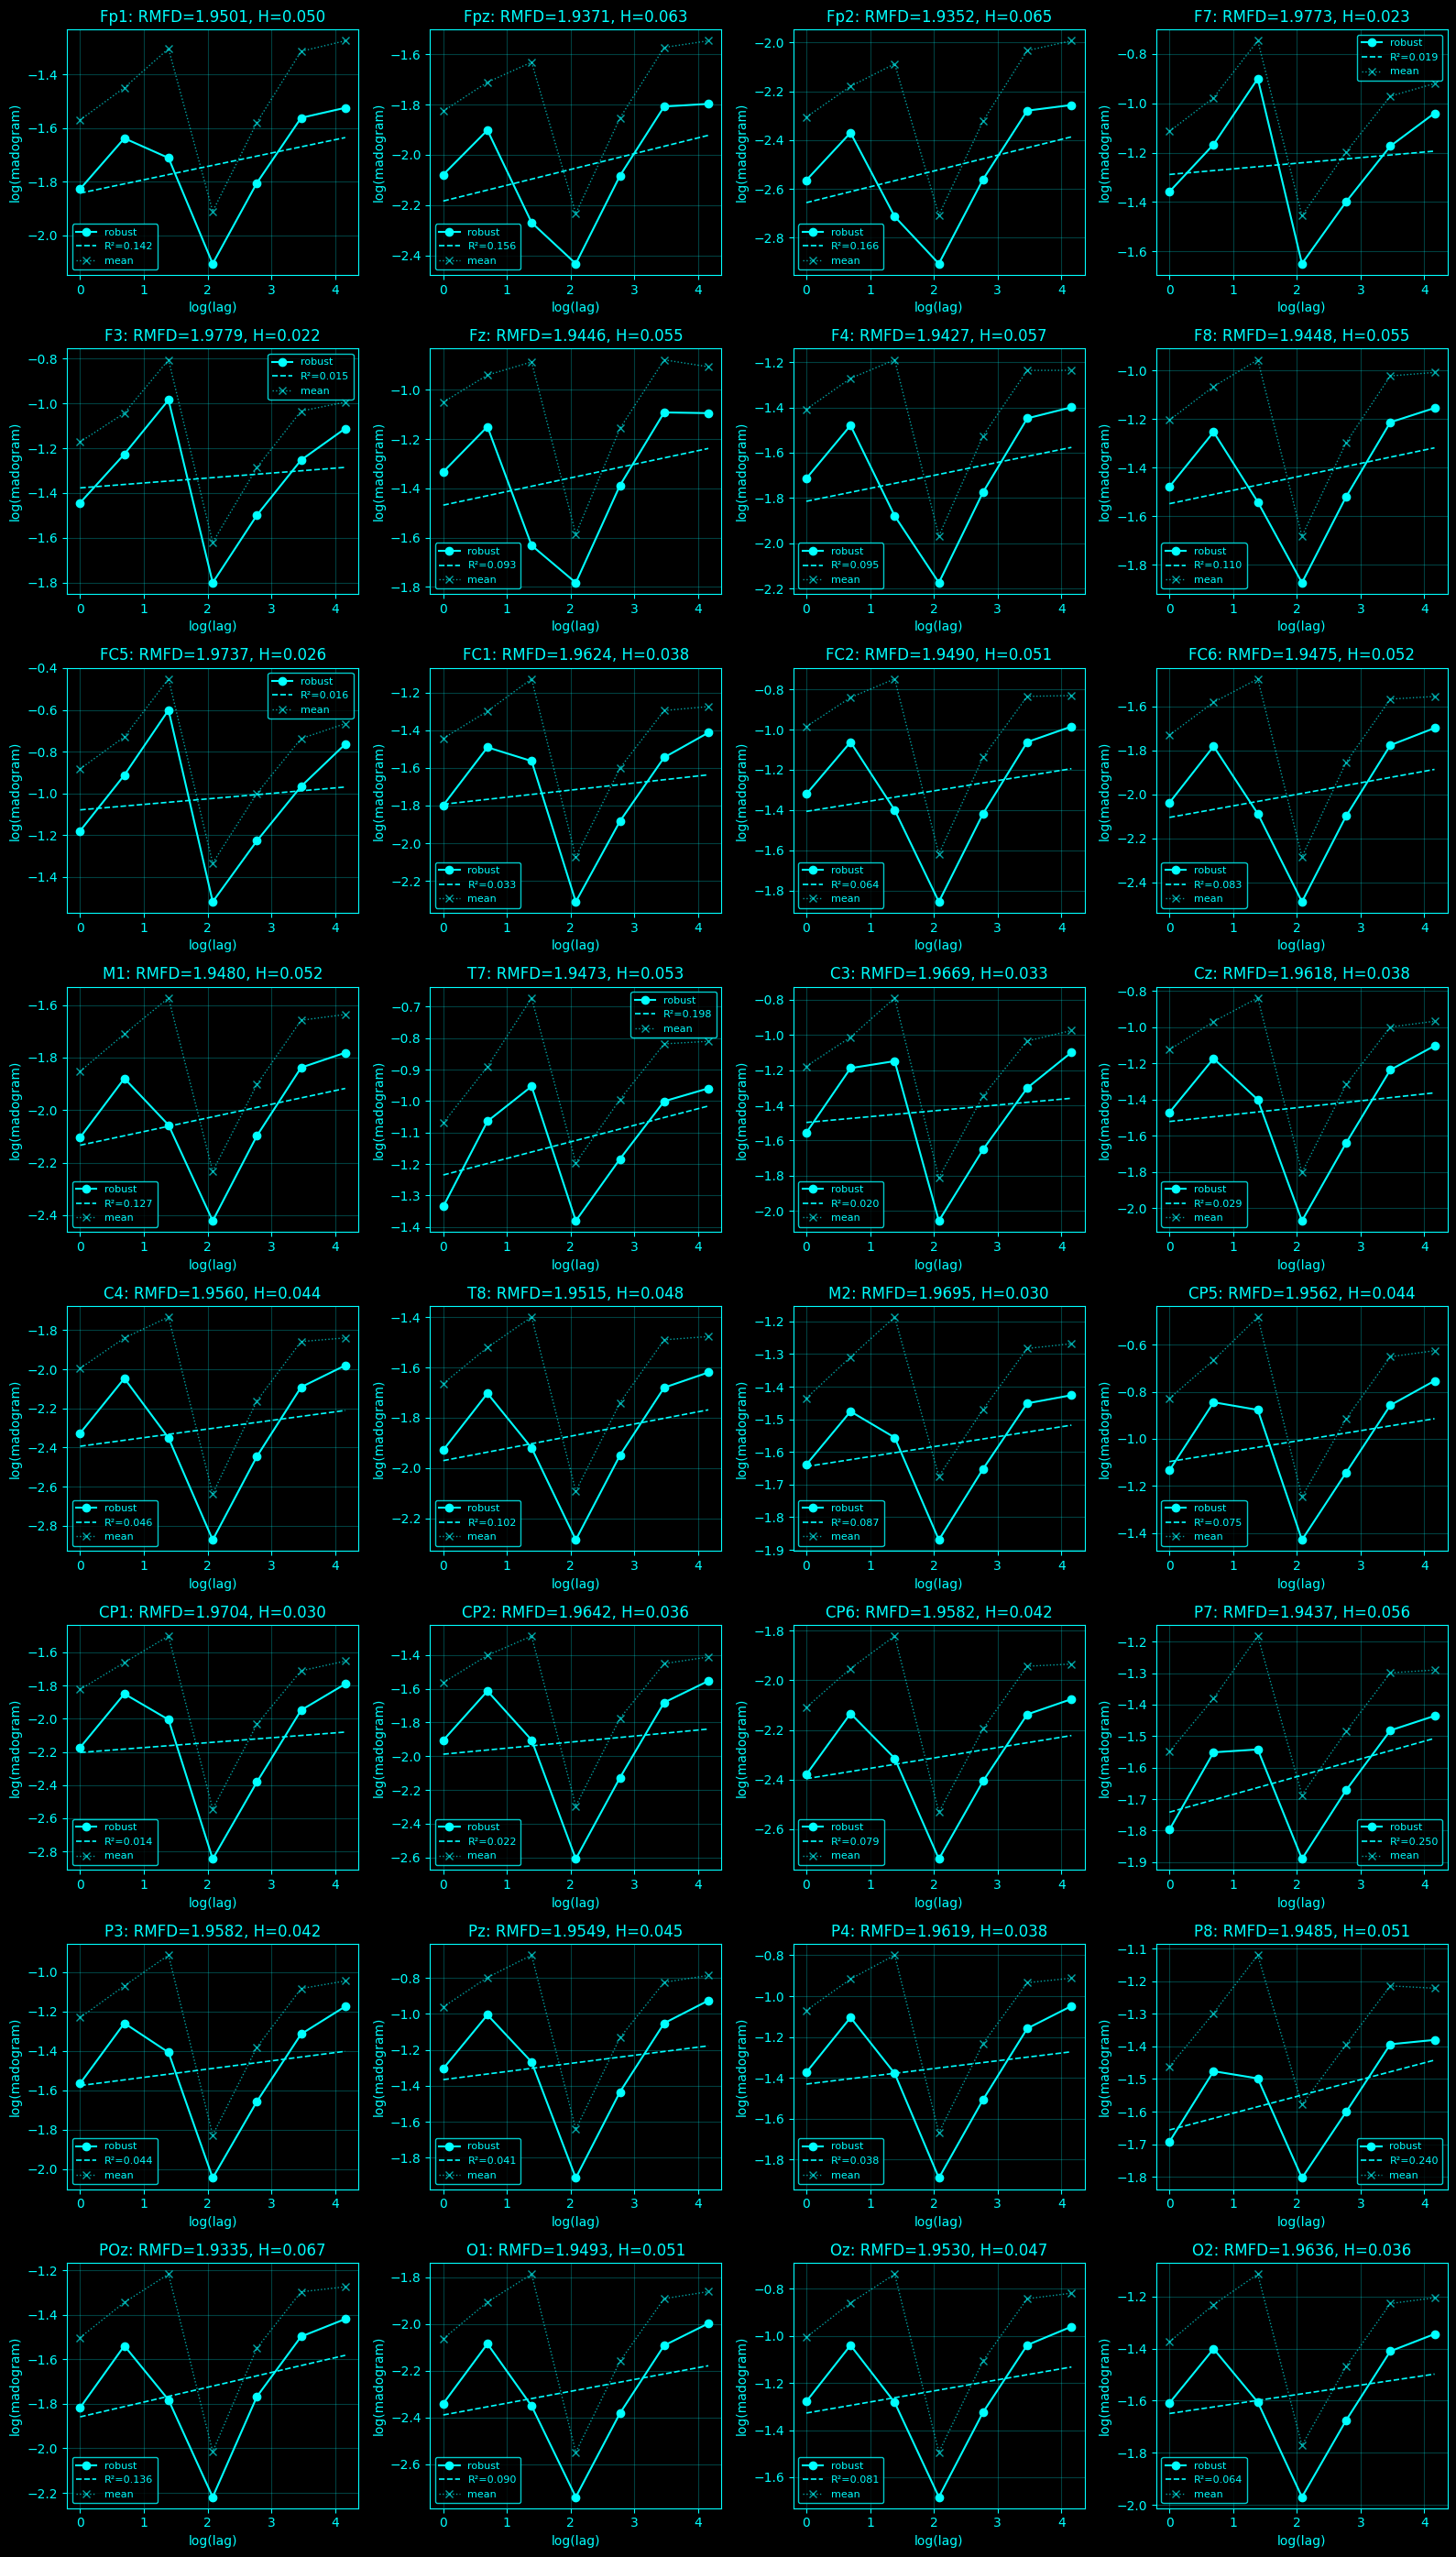

All-channel Madogram fit plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/all_channels_madogram_loglog_fits.png


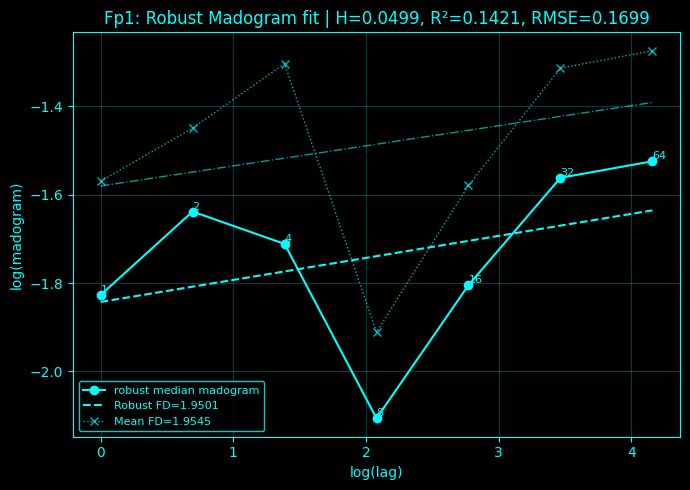

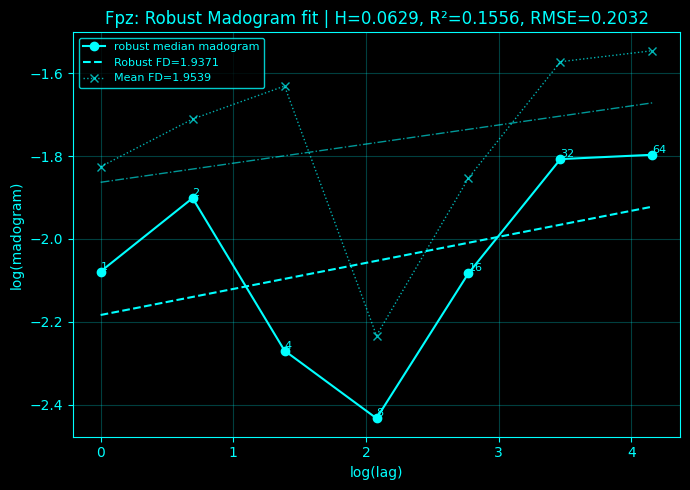

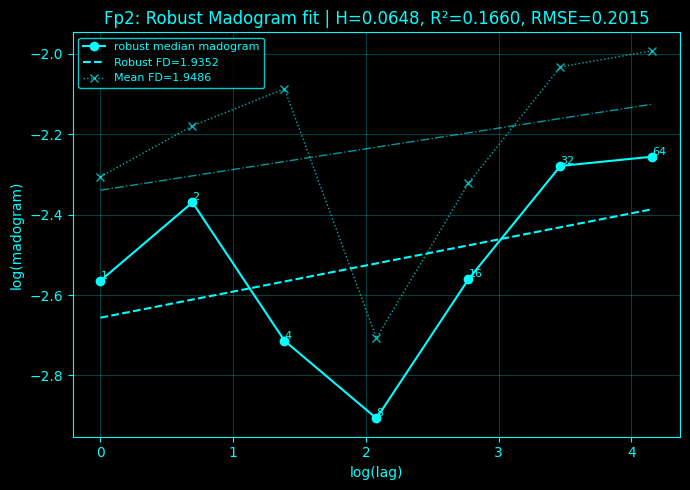

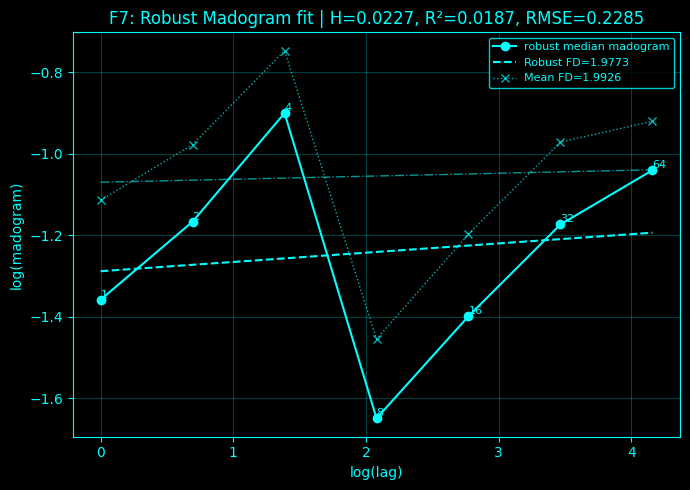

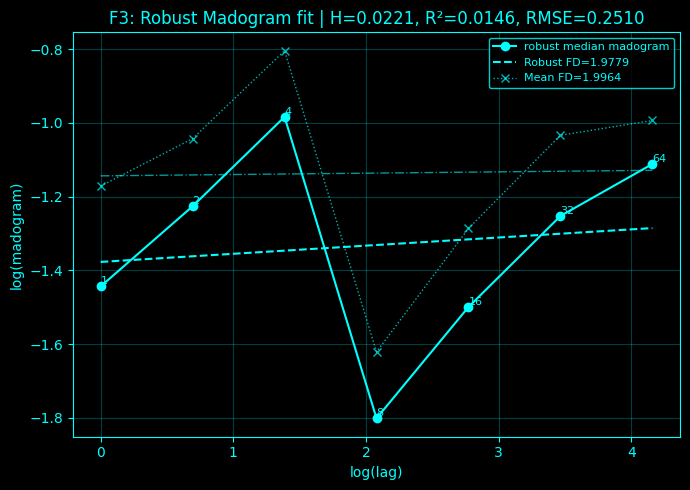

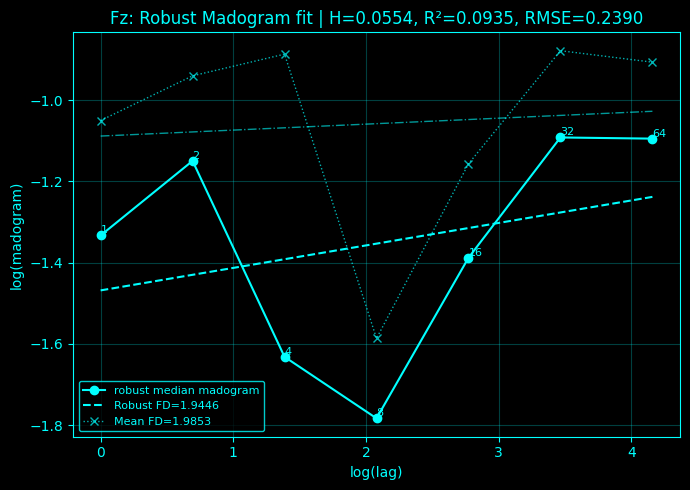

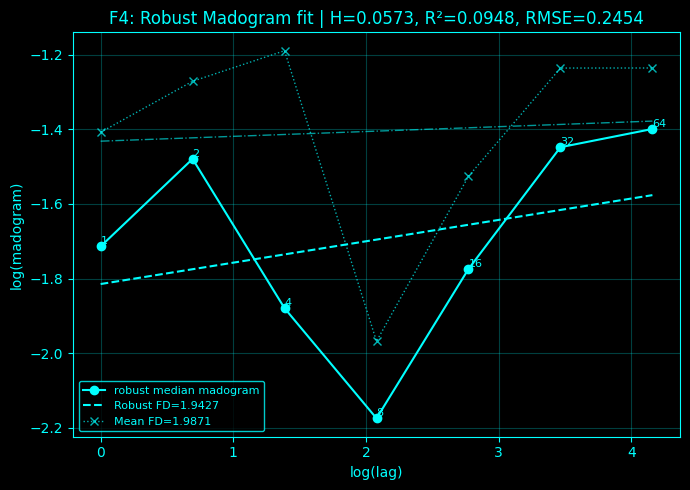

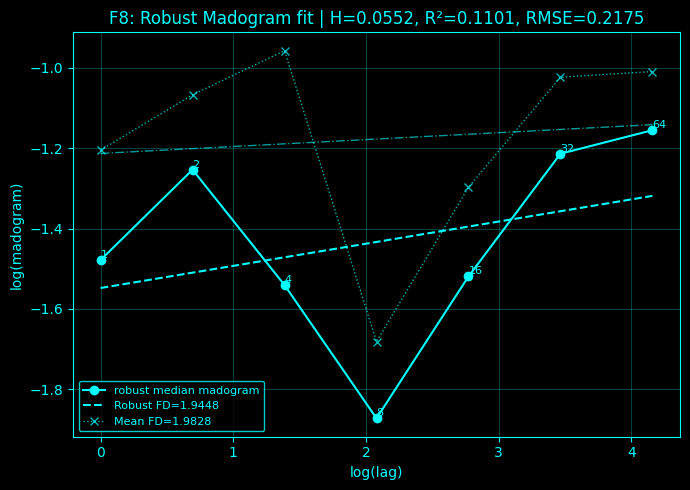

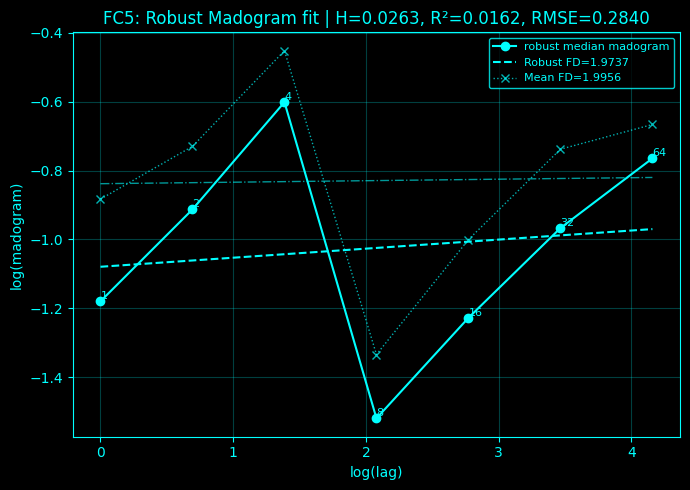

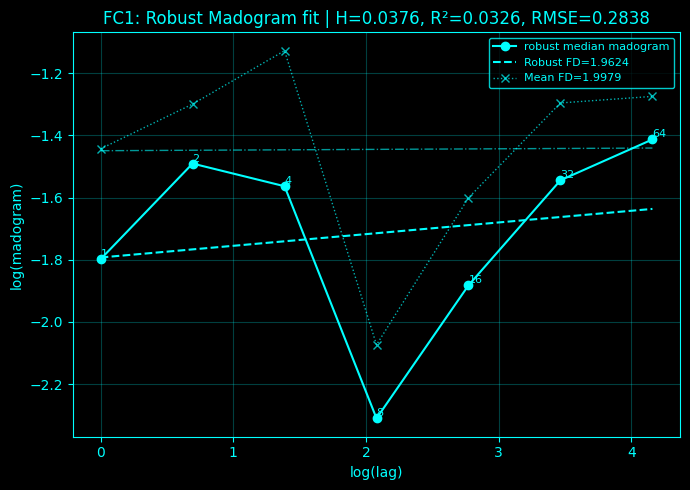

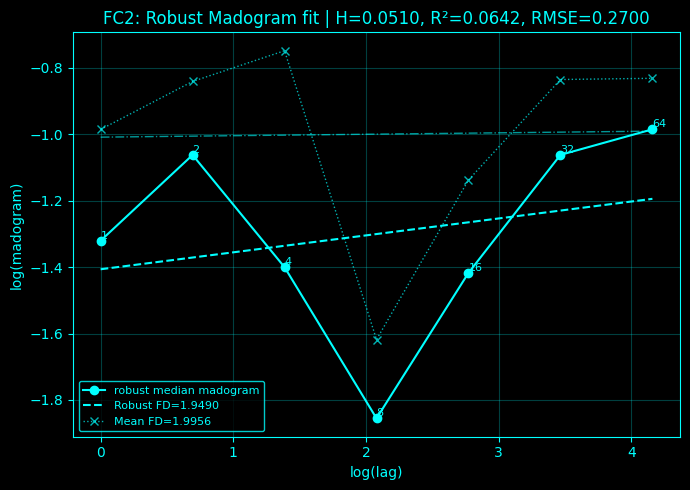

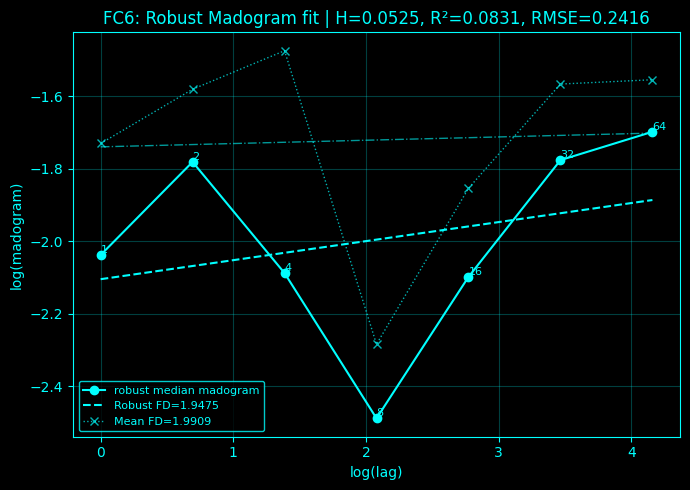

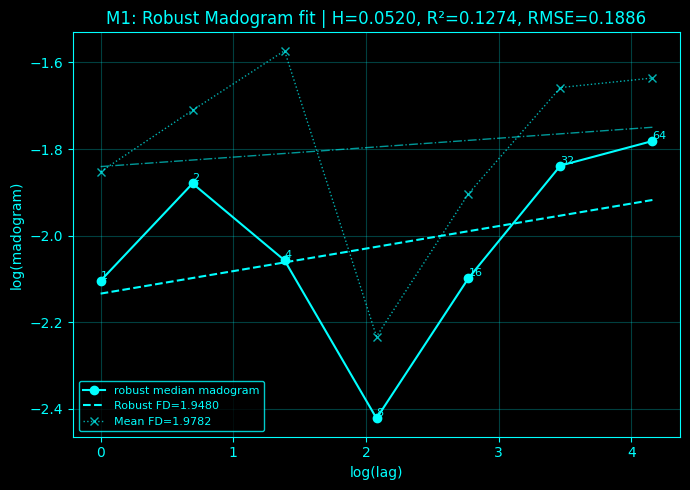

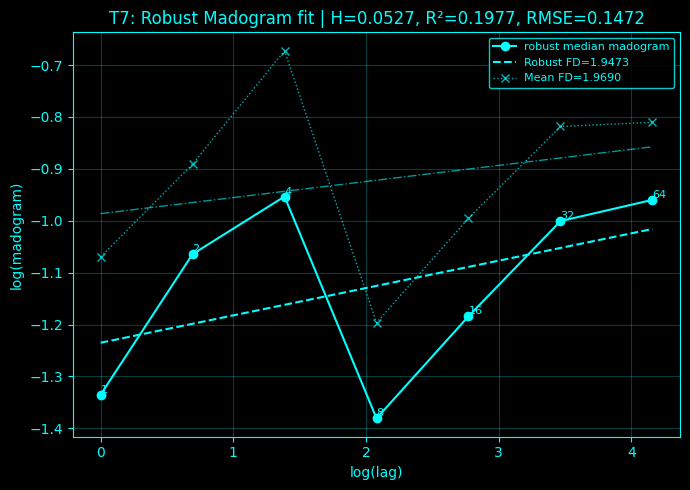

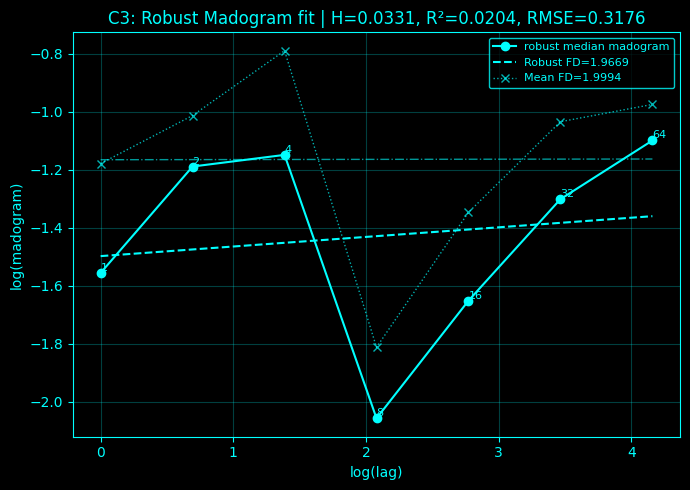

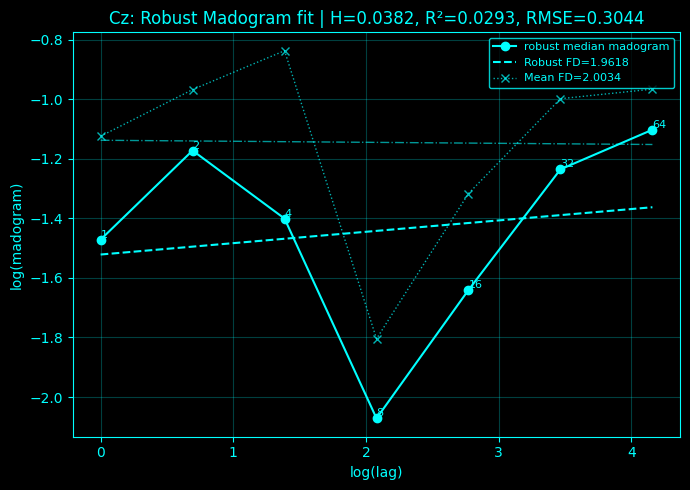

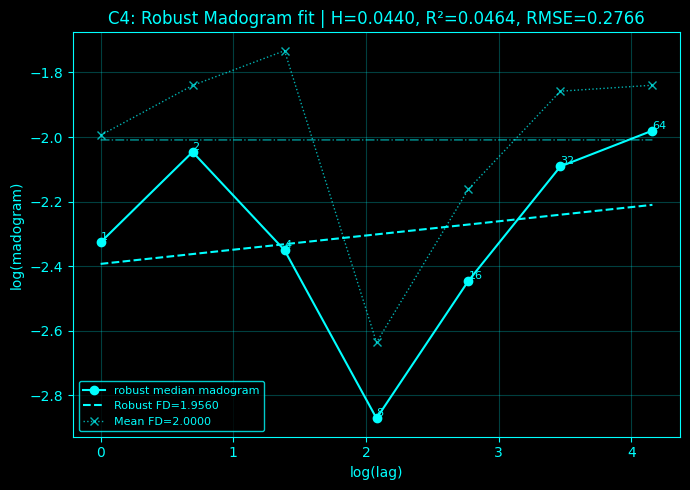

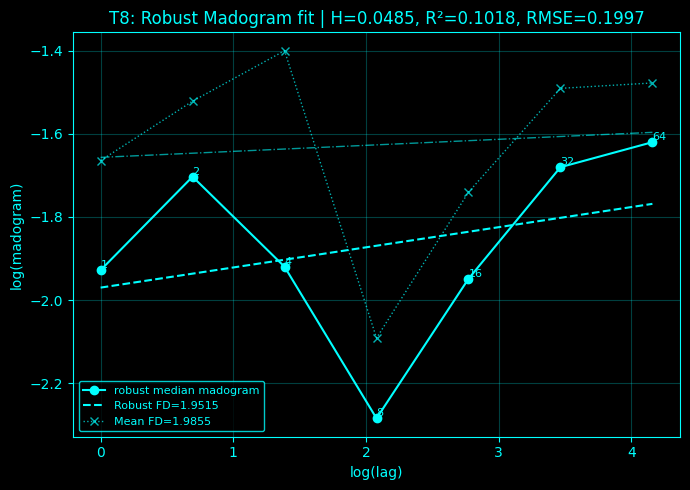

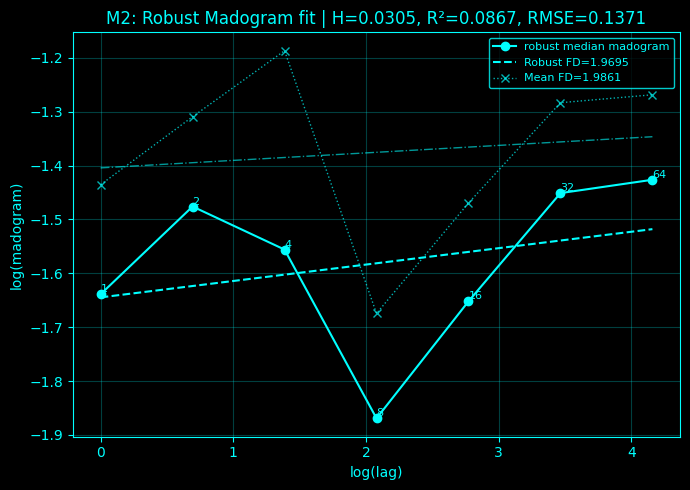

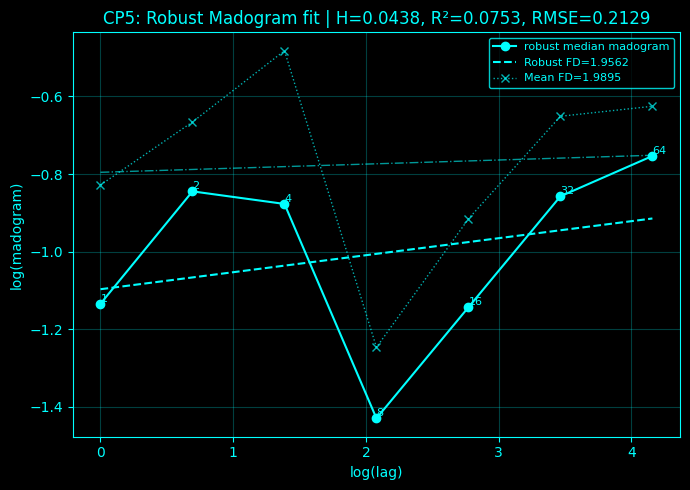

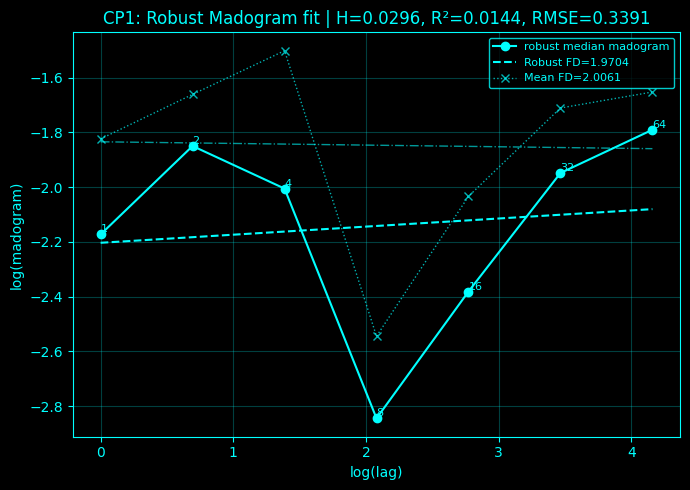

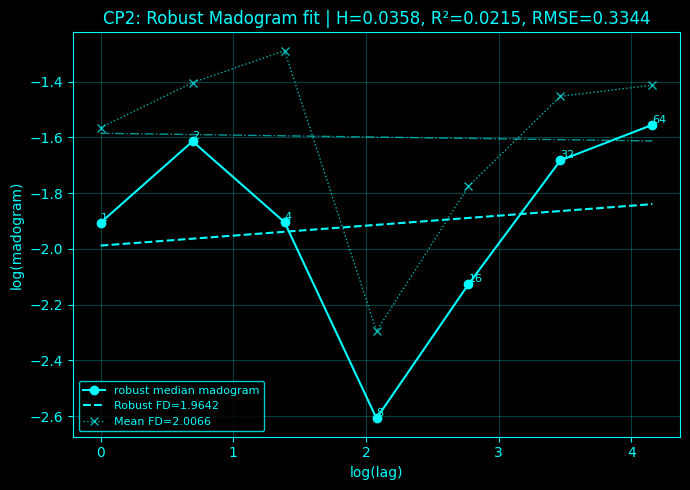

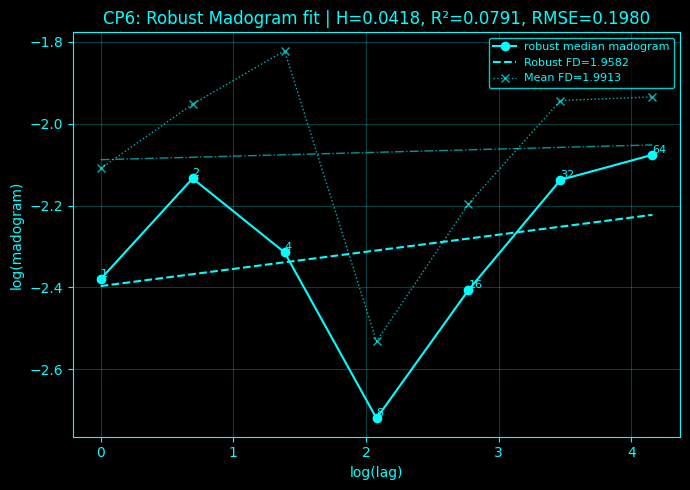

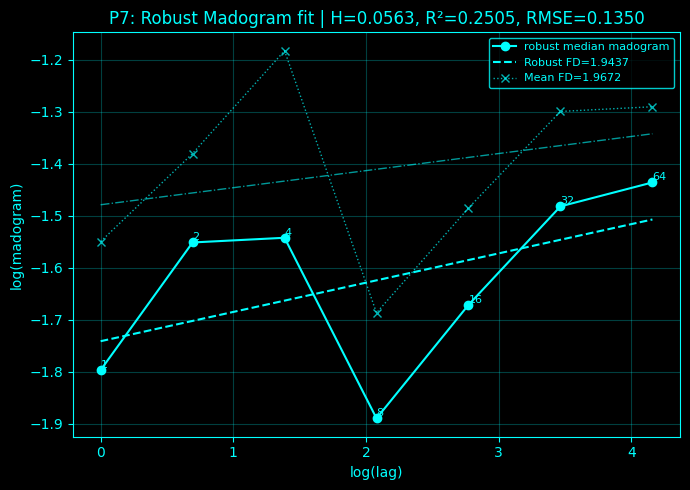

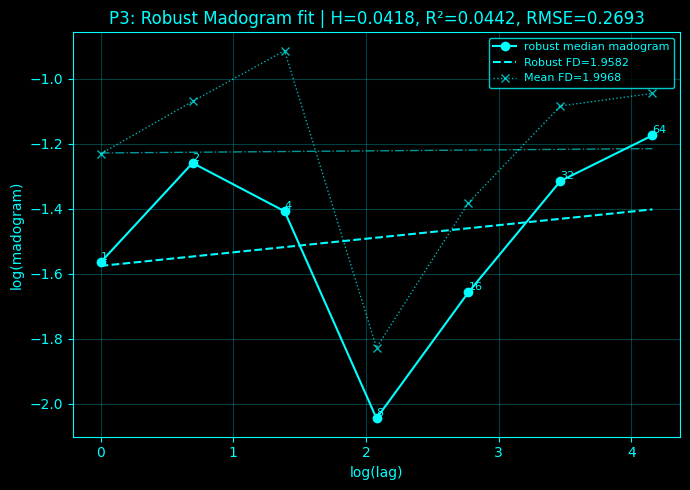

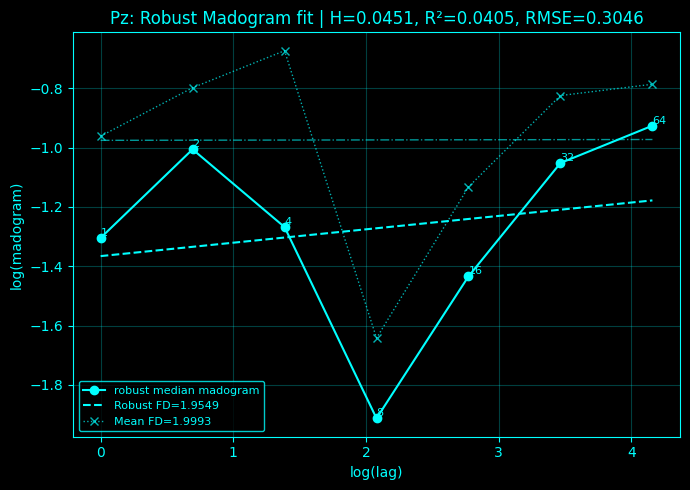

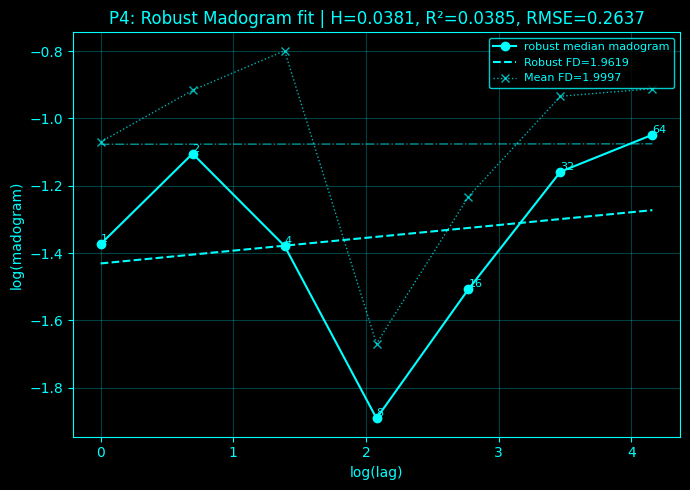

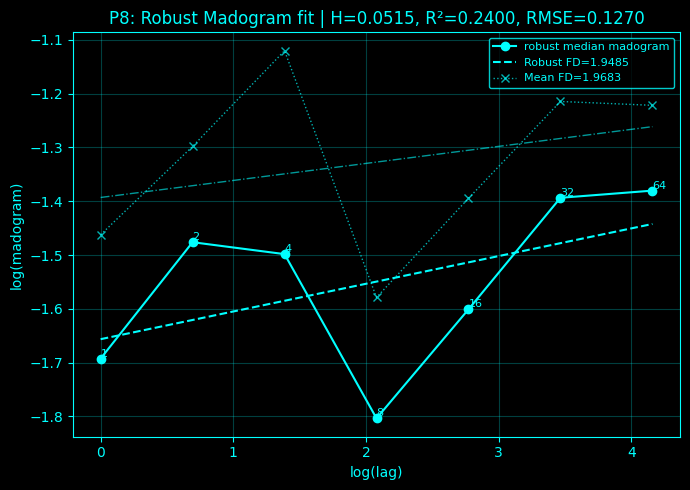

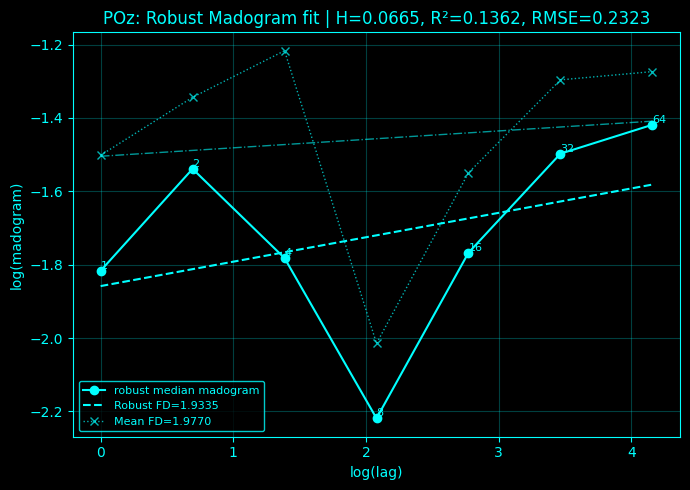

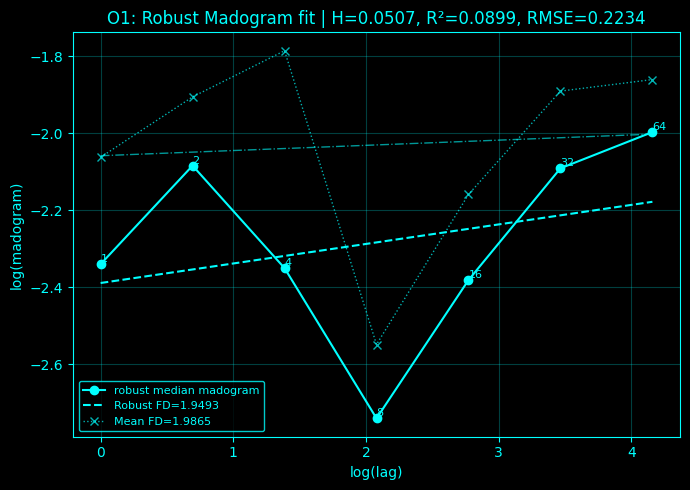

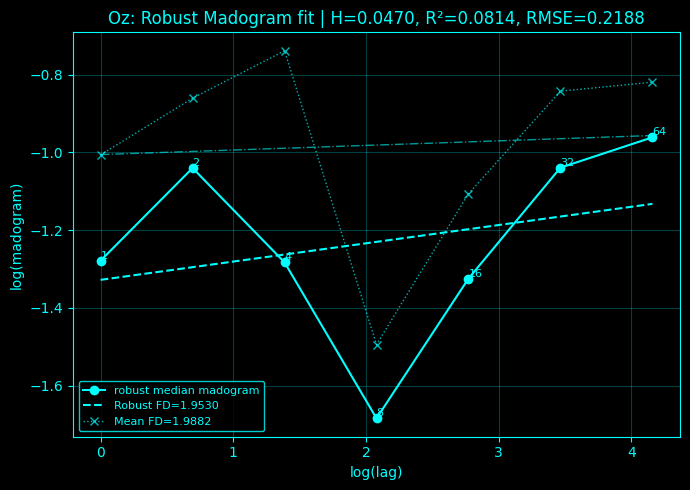

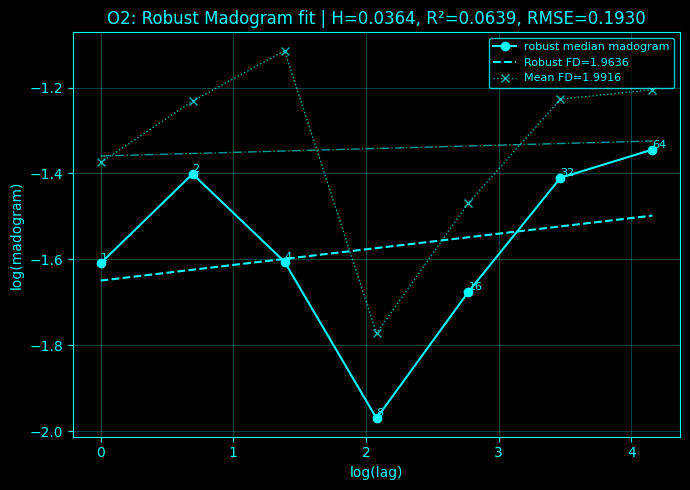

Per-channel Madogram diagnostic plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/per_channel_madogram_diagnostics


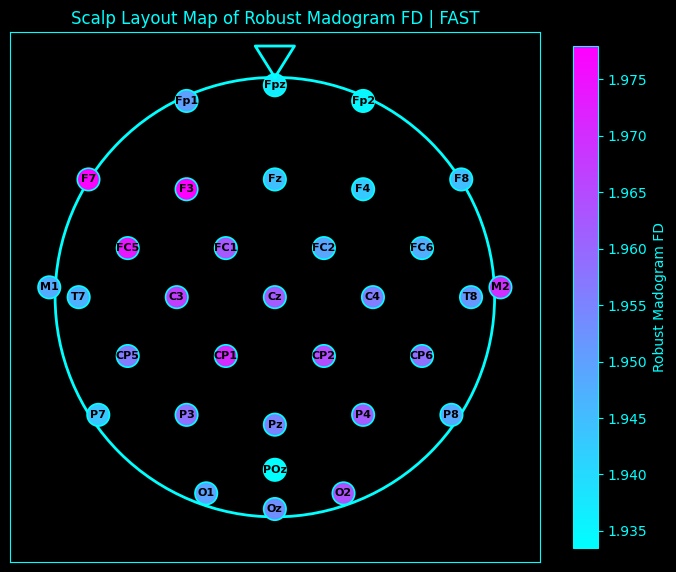

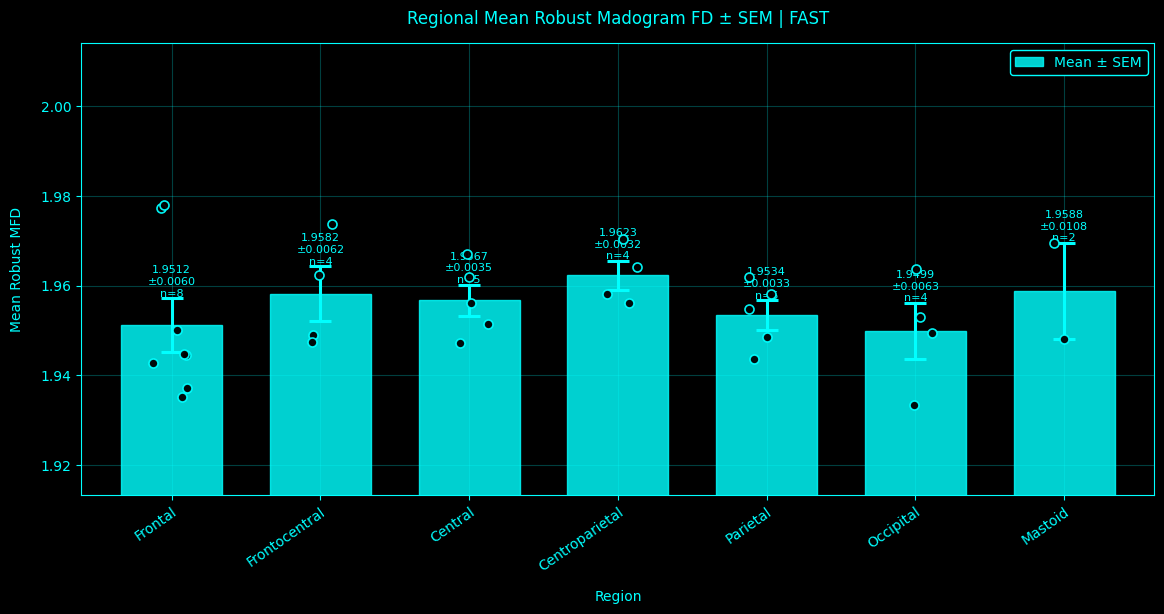

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/regional_madogram_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/regional_madogram_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/regional_madogram_fd_channel_points.csv


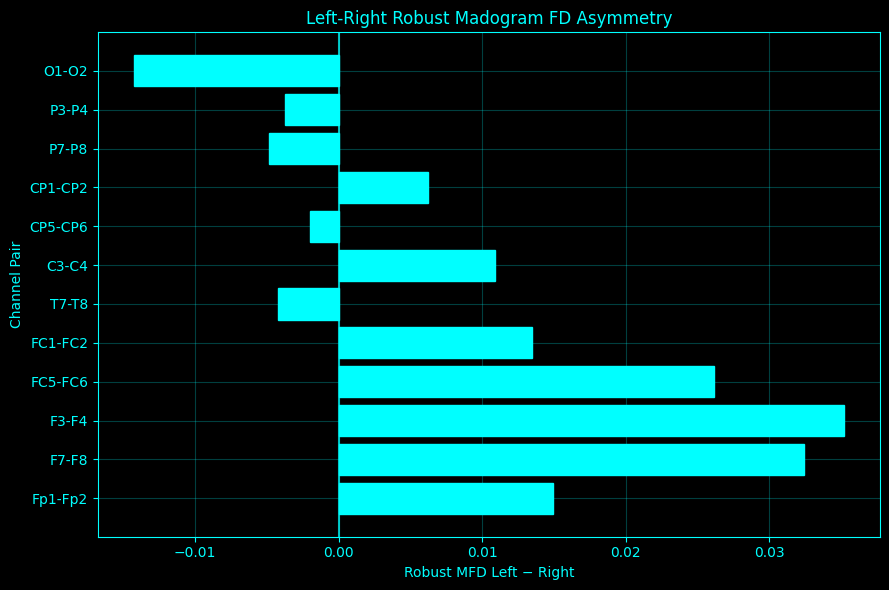

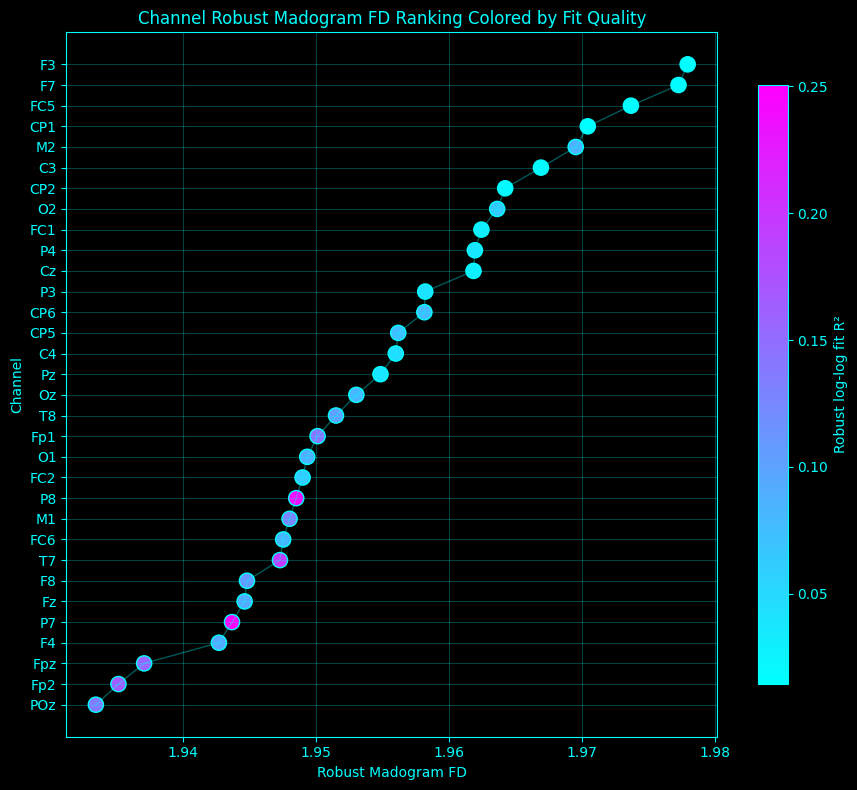

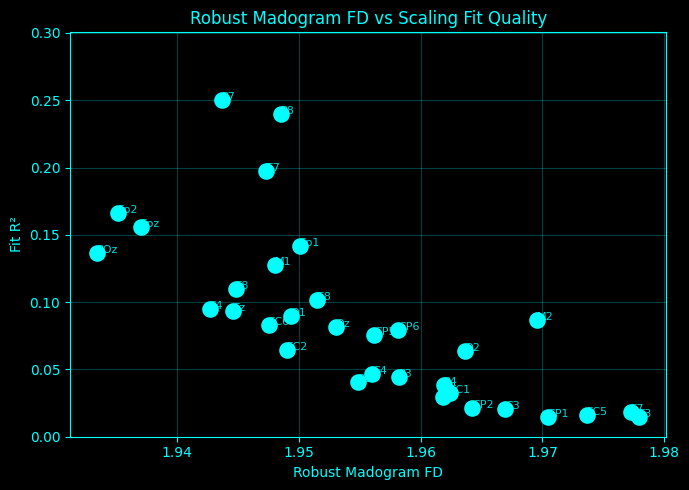

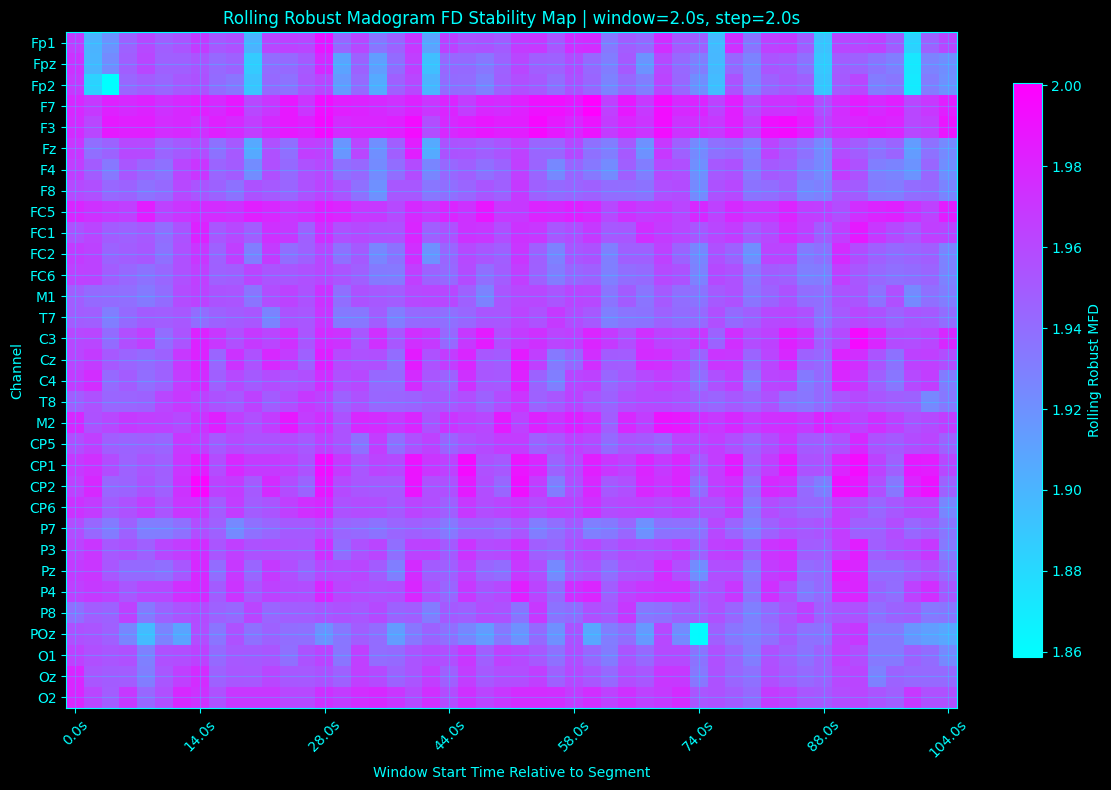

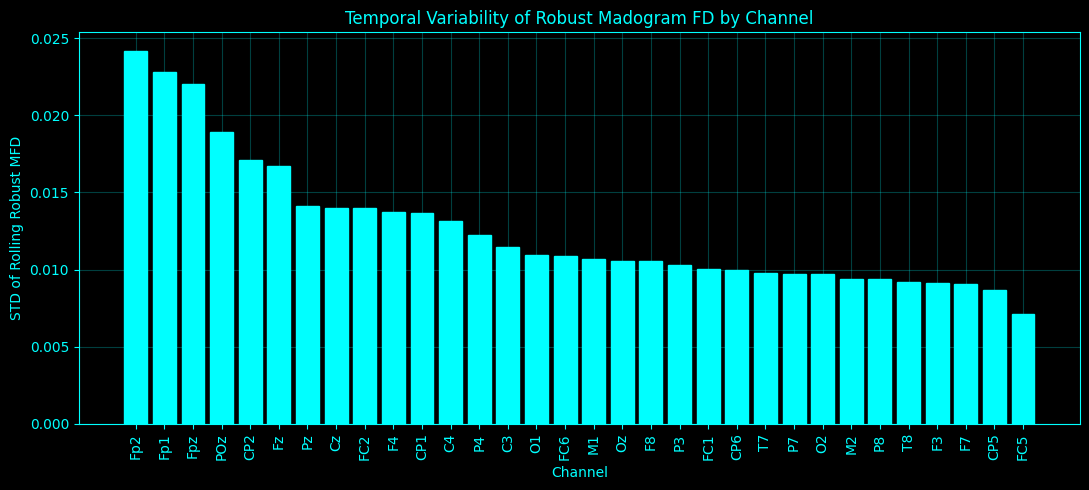

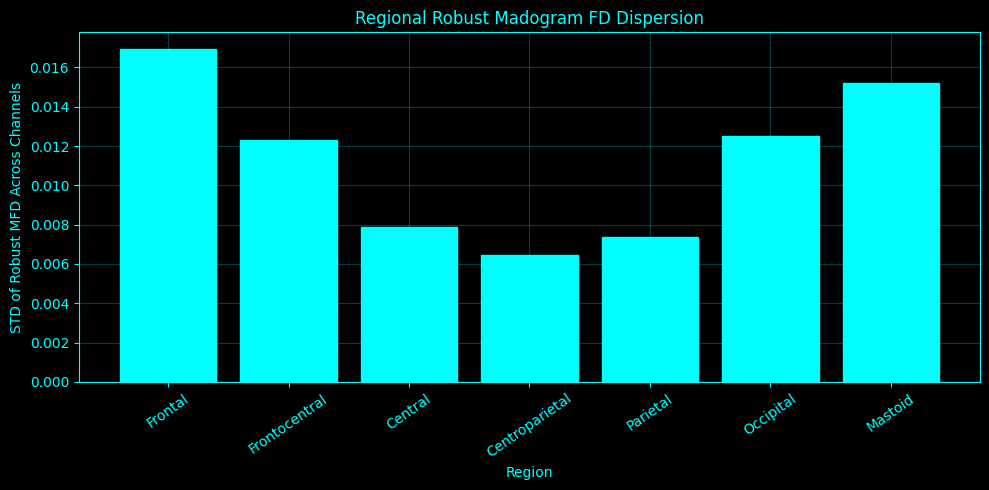

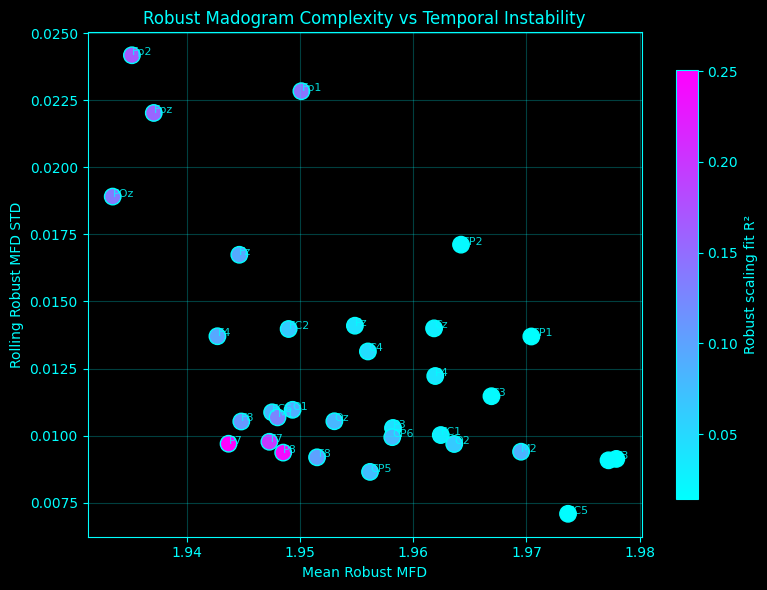

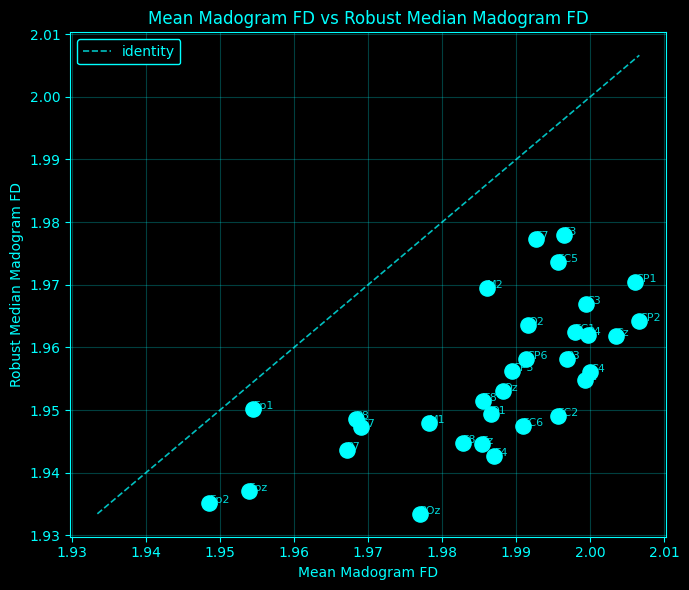


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/regional_madogram_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/left_right_madogram_fd_asymmetry.csv
Rolling Robust MFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/rolling_madogram_fd_by_channel.csv
Rolling Mean MFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/rolling_mean_madogram_fd_by_channel.csv
Rolling fit R² CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/rolling_madogram_fit_r2_by_channel.csv
Rolling Hurst CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_madogram/expert_plots_fast/rolling_madogram

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_madogram")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "decimate": 1,
        "max_samples": None,
        "lags": [1, 2, 4, 8, 16, 32, 64, 128],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 100,
        "expert_plots": True,
    },
    "fast": {
        "decimate": 2,
        "max_samples": 60000,
        "lags": [1, 2, 4, 8, 16, 32, 64],
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 50,
        "expert_plots": True,
    },
    "ultrafast": {
        "decimate": 5,
        "max_samples": 20000,
        "lags": [1, 2, 4, 8, 16, 32],
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 20,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]
madogram_lags = mode_cfg["lags"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Madogram / Robust Variogram FD in {MODE.upper()} mode")
print(f"decimate={decimate}, max_samples={max_samples}, lags={madogram_lags}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# MADOGRAM / ROBUST VARIOGRAM FRACTAL DIMENSION
# -------------------------------------------------------
def fit_loglog_dimension(lags, values, slope_to_hurst_factor=1.0):
    """
    Fit log(values) ~ slope * log(lag) + intercept.

    For madogram:
        madogram(lag) ~ lag^H
        H = slope
        D = 2 - H

    For variogram:
        variogram(lag) ~ lag^(2H)
        H = slope / 2
        D = 2 - H
    """
    lags = np.asarray(lags, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = (
        np.isfinite(lags)
        & np.isfinite(values)
        & (lags > 0)
        & (values > 0)
    )

    if np.sum(mask) < 2:
        return {
            "fd": np.nan,
            "hurst_exponent": np.nan,
            "scaling_slope": np.nan,
            "fit_intercept": np.nan,
            "fit_r2": np.nan,
            "fit_rmse": np.nan,
            "n_valid_scales": int(np.sum(mask)),
        }

    log_lag = np.log(lags[mask])
    log_val = np.log(values[mask])

    slope, intercept = np.polyfit(log_lag, log_val, 1)
    pred = slope * log_lag + intercept

    resid = log_val - pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((log_val - np.mean(log_val)) ** 2)

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = np.sqrt(np.mean(resid ** 2))

    hurst = slope * slope_to_hurst_factor
    fd = 2.0 - hurst

    return {
        "fd": fd,
        "hurst_exponent": hurst,
        "scaling_slope": slope,
        "fit_intercept": intercept,
        "fit_r2": r2,
        "fit_rmse": rmse,
        "n_valid_scales": int(np.sum(mask)),
    }


def madogram_fd(x, lags=None):
    """
    Compute Madogram / Robust Variogram Fractal Dimension for a 1D time series.

    Traditional madogram:
        gamma_M(lag) = 0.5 * mean(|x[t + lag] - x[t]|)

    Robust median madogram:
        gamma_R(lag) = 0.5 * median(|x[t + lag] - x[t]|)

    For a self-affine signal graph:
        gamma_M(lag) ~ lag^H

    Therefore:
        slope = d log(gamma_M) / d log(lag) = H
        D = 2 - H

    Outputs both:
        madogram_fd        = mean-absolute-increment version
        robust_madogram_fd = median-absolute-increment version

    The robust version is less sensitive to EEG spikes/artifacts.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if lags is None:
        lags = [1, 2, 4, 8, 16, 32, 64]

    if N < 8:
        return np.nan, np.nan, None, None, None, {
            "madogram_hurst": np.nan,
            "madogram_slope": np.nan,
            "madogram_intercept": np.nan,
            "madogram_r2": np.nan,
            "madogram_rmse": np.nan,
            "robust_hurst": np.nan,
            "robust_slope": np.nan,
            "robust_intercept": np.nan,
            "robust_r2": np.nan,
            "robust_rmse": np.nan,
            "n_valid_scales": 0,
            "mean_madogram": np.nan,
            "mean_robust_madogram": np.nan,
            "madogram_range": np.nan,
            "robust_madogram_range": np.nan,
        }

    valid_lags = []
    madograms = []
    robust_madograms = []
    mean_abs_increments = []
    median_abs_increments = []
    q25_abs_increments = []
    q75_abs_increments = []

    for lag in lags:
        lag = int(lag)

        if lag < 1 or lag >= N:
            continue

        diffs = x[lag:] - x[:-lag]
        abs_diffs = np.abs(diffs)

        if len(abs_diffs) < 3:
            continue

        mean_abs = np.mean(abs_diffs)
        median_abs = np.median(abs_diffs)
        q25_abs = np.percentile(abs_diffs, 25)
        q75_abs = np.percentile(abs_diffs, 75)

        gamma_m = 0.5 * mean_abs
        gamma_r = 0.5 * median_abs

        if np.isfinite(gamma_m) and gamma_m > 0 and np.isfinite(gamma_r) and gamma_r > 0:
            valid_lags.append(lag)
            madograms.append(gamma_m)
            robust_madograms.append(gamma_r)
            mean_abs_increments.append(mean_abs)
            median_abs_increments.append(median_abs)
            q25_abs_increments.append(q25_abs)
            q75_abs_increments.append(q75_abs)

    valid_lags = np.asarray(valid_lags, dtype=int)
    madograms = np.asarray(madograms, dtype=float)
    robust_madograms = np.asarray(robust_madograms, dtype=float)
    mean_abs_increments = np.asarray(mean_abs_increments, dtype=float)
    median_abs_increments = np.asarray(median_abs_increments, dtype=float)
    q25_abs_increments = np.asarray(q25_abs_increments, dtype=float)
    q75_abs_increments = np.asarray(q75_abs_increments, dtype=float)

    mad_fit = fit_loglog_dimension(
        valid_lags,
        madograms,
        slope_to_hurst_factor=1.0
    )

    robust_fit = fit_loglog_dimension(
        valid_lags,
        robust_madograms,
        slope_to_hurst_factor=1.0
    )

    mad_fd = mad_fit["fd"]
    robust_fd = robust_fit["fd"]

    return mad_fd, robust_fd, valid_lags, madograms, robust_madograms, {
        "madogram_hurst": mad_fit["hurst_exponent"],
        "madogram_slope": mad_fit["scaling_slope"],
        "madogram_intercept": mad_fit["fit_intercept"],
        "madogram_r2": mad_fit["fit_r2"],
        "madogram_rmse": mad_fit["fit_rmse"],
        "robust_hurst": robust_fit["hurst_exponent"],
        "robust_slope": robust_fit["scaling_slope"],
        "robust_intercept": robust_fit["fit_intercept"],
        "robust_r2": robust_fit["fit_r2"],
        "robust_rmse": robust_fit["fit_rmse"],
        "n_valid_scales": robust_fit["n_valid_scales"],
        "mean_madogram": np.nanmean(madograms) if len(madograms) else np.nan,
        "mean_robust_madogram": np.nanmean(robust_madograms) if len(robust_madograms) else np.nan,
        "madogram_range": (
            np.nanmax(madograms) - np.nanmin(madograms)
            if len(madograms) else np.nan
        ),
        "robust_madogram_range": (
            np.nanmax(robust_madograms) - np.nanmin(robust_madograms)
            if len(robust_madograms) else np.nan
        ),
        "mean_abs_increments": mean_abs_increments,
        "median_abs_increments": median_abs_increments,
        "q25_abs_increments": q25_abs_increments,
        "q75_abs_increments": q75_abs_increments,
    }

# -------------------------------------------------------
# RUN MADOGRAM FD PER CHANNEL
# -------------------------------------------------------
rows = {}
curves = {}
diagnostic_rows = []

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    mad_fd, robust_fd, lags_used, madograms, robust_madograms, diag = madogram_fd(
        x,
        lags=madogram_lags
    )

    rows[ch_name] = {
        "channel": ch_name,
        "madogram_fd": mad_fd,
        "robust_madogram_fd": robust_fd,

        "madogram_hurst": diag["madogram_hurst"],
        "madogram_slope": diag["madogram_slope"],
        "madogram_intercept": diag["madogram_intercept"],
        "madogram_r2": diag["madogram_r2"],
        "madogram_rmse": diag["madogram_rmse"],

        "robust_hurst": diag["robust_hurst"],
        "robust_slope": diag["robust_slope"],
        "robust_intercept": diag["robust_intercept"],
        "robust_r2": diag["robust_r2"],
        "robust_rmse": diag["robust_rmse"],

        "n_valid_scales": diag["n_valid_scales"],
        "mean_madogram": diag["mean_madogram"],
        "mean_robust_madogram": diag["mean_robust_madogram"],
        "madogram_range": diag["madogram_range"],
        "robust_madogram_range": diag["robust_madogram_range"],
    }

    curves[ch_name] = {
        "lags": lags_used,
        "madograms": madograms,
        "robust_madograms": robust_madograms,
        "mean_abs_increments": diag.get("mean_abs_increments", None),
        "median_abs_increments": diag.get("median_abs_increments", None),
        "q25_abs_increments": diag.get("q25_abs_increments", None),
        "q75_abs_increments": diag.get("q75_abs_increments", None),
    }

    diagnostic_rows.append(rows[ch_name])

results_df = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("robust_madogram_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "madogram_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nMadogram / Robust Variogram Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# SAVE DIAGNOSTIC TABLE
# -------------------------------------------------------
diagnostics_df = results_df.copy()

diagnostics_csv_path = os.path.join(out_dir, "madogram_fd_diagnostics.csv")
diagnostics_df.to_csv(diagnostics_csv_path, index=False)

print(f"\nDiagnostics CSV: {diagnostics_csv_path}")

# -------------------------------------------------------
# PLOT 1: FIXED ROBUST MADOGRAM FD BY CHANNEL PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

plot_df = results_df.copy().sort_values("robust_madogram_fd", ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
y = plot_df["robust_madogram_fd"].to_numpy(dtype=float)

finite_y = y[np.isfinite(y)]

if len(finite_y) == 0:
    y_min, y_max, y_range = 0.0, 1.0, 1.0
else:
    y_min = np.nanmin(finite_y)
    y_max = np.nanmax(finite_y)
    y_range = y_max - y_min

if not np.isfinite(y_range) or y_range <= 0:
    y_range = 0.001

pad = max(0.0005, y_range * 0.35)
baseline = y_min - pad * 0.6

ax.vlines(
    x_pos,
    baseline,
    y,
    color=ACCENT,
    linewidth=1.8,
    alpha=0.75
)

ax.scatter(
    x_pos,
    y,
    s=85,
    facecolors=BG,
    edgecolors=ACCENT,
    linewidths=1.8,
    zorder=4,
    label="Robust Madogram FD"
)

mean_rfd = np.nanmean(y)

ax.axhline(
    mean_rfd,
    color=ACCENT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.75,
    label=f"Mean={mean_rfd:.5f}"
)

top_n = min(4, len(plot_df))
label_indices = list(range(top_n)) + list(range(len(plot_df) - top_n, len(plot_df)))

for i in sorted(set(label_indices)):
    if np.isfinite(y[i]):
        ax.text(
            x_pos[i],
            y[i] + pad * 0.12,
            f"{y[i]:.5f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=ACCENT,
            rotation=90
        )

ax.set_ylim(baseline, y_max + pad * 1.3)

ax.set_title(f"Robust Madogram Fractal Dimension by Channel | {MODE.upper()}", pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("Robust MFD")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ax.legend(loc="best", framealpha=1.0)

bar_path = os.path.join(out_dir, "madogram_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ALL-CHANNEL MADOGRAM LOG-LOG FITS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    d = curves[ch_name]
    lags_used = d["lags"]
    madograms = d["madograms"]
    robust_madograms = d["robust_madograms"]

    robust_fd_val = rows[ch_name]["robust_madogram_fd"]
    robust_hurst = rows[ch_name]["robust_hurst"]
    robust_slope = rows[ch_name]["robust_slope"]
    robust_intercept = rows[ch_name]["robust_intercept"]
    robust_r2 = rows[ch_name]["robust_r2"]

    if lags_used is None or robust_madograms is None:
        ax.set_title(f"{ch_name}: no data")
        ax.axis("off")
        continue

    mask = (
        np.isfinite(lags_used)
        & np.isfinite(robust_madograms)
        & (lags_used > 0)
        & (robust_madograms > 0)
    )

    if np.sum(mask) < 2:
        ax.set_title(f"{ch_name}: insufficient data")
        ax.axis("off")
        continue

    log_lag = np.log(lags_used[mask].astype(float))
    log_robust = np.log(robust_madograms[mask])
    robust_fit_line = robust_slope * log_lag + robust_intercept

    ax.plot(
        log_lag,
        log_robust,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        linewidth=1.5,
        label="robust"
    )

    ax.plot(
        log_lag,
        robust_fit_line,
        color=ACCENT,
        linestyle="--",
        linewidth=1.2,
        label=f"R²={robust_r2:.3f}"
    )

    if madograms is not None:
        mad_mask = (
            np.isfinite(lags_used)
            & np.isfinite(madograms)
            & (lags_used > 0)
            & (madograms > 0)
        )

        if np.sum(mad_mask) >= 2:
            ax.plot(
                np.log(lags_used[mad_mask].astype(float)),
                np.log(madograms[mad_mask]),
                marker="x",
                color=ACCENT,
                linestyle=":",
                linewidth=1.0,
                alpha=0.65,
                label="mean"
            )

    ax.set_title(f"{ch_name}: RMFD={robust_fd_val:.4f}, H={robust_hurst:.3f}")
    ax.set_xlabel("log(lag)")
    ax.set_ylabel("log(madogram)")
    ax.legend(fontsize=8)

for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_fits_path = os.path.join(out_dir, "all_channels_madogram_loglog_fits.png")
plt.tight_layout()
plt.savefig(all_fits_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Madogram fit plot saved to: {all_fits_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE DIAGNOSTIC PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_madogram_diagnostics")
os.makedirs(per_channel_dir, exist_ok=True)

for ch_name in eeg_channels:
    d = curves[ch_name]
    lags_used = d["lags"]
    madograms = d["madograms"]
    robust_madograms = d["robust_madograms"]

    mad_fd_val = rows[ch_name]["madogram_fd"]
    robust_fd_val = rows[ch_name]["robust_madogram_fd"]

    mad_hurst = rows[ch_name]["madogram_hurst"]
    robust_hurst = rows[ch_name]["robust_hurst"]

    mad_slope = rows[ch_name]["madogram_slope"]
    mad_intercept = rows[ch_name]["madogram_intercept"]
    mad_r2 = rows[ch_name]["madogram_r2"]

    robust_slope = rows[ch_name]["robust_slope"]
    robust_intercept = rows[ch_name]["robust_intercept"]
    robust_r2 = rows[ch_name]["robust_r2"]
    robust_rmse = rows[ch_name]["robust_rmse"]

    if lags_used is None or robust_madograms is None:
        continue

    robust_mask = (
        np.isfinite(lags_used)
        & np.isfinite(robust_madograms)
        & (lags_used > 0)
        & (robust_madograms > 0)
    )

    if np.sum(robust_mask) < 2:
        continue

    log_lag = np.log(lags_used[robust_mask].astype(float))
    log_robust = np.log(robust_madograms[robust_mask])
    robust_fit_line = robust_slope * log_lag + robust_intercept

    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        log_lag,
        log_robust,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        label="robust median madogram"
    )

    ax.plot(
        log_lag,
        robust_fit_line,
        color=ACCENT,
        linestyle="--",
        label=f"Robust FD={robust_fd_val:.4f}"
    )

    if madograms is not None:
        mad_mask = (
            np.isfinite(lags_used)
            & np.isfinite(madograms)
            & (lags_used > 0)
            & (madograms > 0)
        )

        if np.sum(mad_mask) >= 2:
            log_lag_m = np.log(lags_used[mad_mask].astype(float))
            log_mad = np.log(madograms[mad_mask])
            mad_fit_line = mad_slope * log_lag_m + mad_intercept

            ax.plot(
                log_lag_m,
                log_mad,
                marker="x",
                color=ACCENT,
                linestyle=":",
                linewidth=1.0,
                alpha=0.7,
                label=f"Mean FD={mad_fd_val:.4f}"
            )

            ax.plot(
                log_lag_m,
                mad_fit_line,
                color=ACCENT,
                linestyle="-.",
                linewidth=1.0,
                alpha=0.6
            )

    for xd, yd, lag in zip(log_lag, log_robust, np.asarray(lags_used)[robust_mask]):
        ax.text(
            xd,
            yd,
            f"{lag}",
            fontsize=8,
            color=ACCENT,
            ha="left",
            va="bottom"
        )

    ax.set_title(
        f"{ch_name}: Robust Madogram fit | H={robust_hurst:.4f}, "
        f"R²={robust_r2:.4f}, RMSE={robust_rmse:.4f}"
    )

    ax.set_xlabel("log(lag)")
    ax.set_ylabel("log(madogram)")
    ax.legend(fontsize=8)

    diag_path = os.path.join(per_channel_dir, f"{ch_name}_madogram_diagnostic.png")
    plt.tight_layout()
    plt.savefig(diag_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Madogram diagnostic plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "madogram_fd_curves.npz")

save_dict = {
    "channels": np.asarray(eeg_channels),
    "madogram_fd": np.asarray([rows[ch]["madogram_fd"] for ch in eeg_channels], dtype=float),
    "robust_madogram_fd": np.asarray([rows[ch]["robust_madogram_fd"] for ch in eeg_channels], dtype=float),
    "madogram_hurst": np.asarray([rows[ch]["madogram_hurst"] for ch in eeg_channels], dtype=float),
    "robust_hurst": np.asarray([rows[ch]["robust_hurst"] for ch in eeg_channels], dtype=float),
    "madogram_r2": np.asarray([rows[ch]["madogram_r2"] for ch in eeg_channels], dtype=float),
    "robust_r2": np.asarray([rows[ch]["robust_r2"] for ch in eeg_channels], dtype=float),
    "robust_rmse": np.asarray([rows[ch]["robust_rmse"] for ch in eeg_channels], dtype=float),
}

for ch_name, d in curves.items():
    if d["lags"] is not None:
        save_dict[f"{ch_name}_lags"] = d["lags"]
    if d["madograms"] is not None:
        save_dict[f"{ch_name}_madogram"] = d["madograms"]
    if d["robust_madograms"] is not None:
        save_dict[f"{ch_name}_robust_madogram"] = d["robust_madograms"]
    if d["mean_abs_increments"] is not None:
        save_dict[f"{ch_name}_mean_abs_increments"] = d["mean_abs_increments"]
    if d["median_abs_increments"] is not None:
        save_dict[f"{ch_name}_median_abs_increments"] = d["median_abs_increments"]
    if d["q25_abs_increments"] is not None:
        save_dict[f"{ch_name}_q25_abs_increments"] = d["q25_abs_increments"]
    if d["q75_abs_increments"] is not None:
        save_dict[f"{ch_name}_q75_abs_increments"] = d["q75_abs_increments"]

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    rfd_map = dict(zip(results_df["channel"], results_df["robust_madogram_fd"]))
    mfd_map = dict(zip(results_df["channel"], results_df["madogram_fd"]))
    hurst_map = dict(zip(results_df["channel"], results_df["robust_hurst"]))
    slope_map = dict(zip(results_df["channel"], results_df["robust_slope"]))
    r2_map = dict(zip(results_df["channel"], results_df["robust_r2"]))
    madogram_map = dict(zip(results_df["channel"], results_df["mean_robust_madogram"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT ROBUST MADOGRAM FD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in rfd_map and np.isfinite(rfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(rfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Robust Madogram FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Robust Madogram FD | {MODE.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "madogram_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL ROBUST MADOGRAM FD SUMMARY
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in rfd_map and np.isfinite(rfd_map[ch]):
                vals_region.append(rfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "robust_madogram_fd": rfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_robust_mfd": np.mean(vals_region),
            "std_robust_mfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_robust_mfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_madogram_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_madogram_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x_region = np.arange(len(region_df))

    ax.bar(
        x_region,
        region_df["mean_robust_mfd"],
        yerr=region_df["sem_robust_mfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "robust_madogram_fd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y_val = row["mean_robust_mfd"]
        sem = row["sem_robust_mfd"]

        ax.text(
            i,
            y_val + sem,
            f"{y_val:.4f}\n±{sem:.4f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["robust_madogram_fd"].to_numpy(dtype=float)
    all_sem_upper = (
        region_df["mean_robust_mfd"].to_numpy(dtype=float)
        + region_df["sem_robust_mfd"].to_numpy(dtype=float)
    )
    all_sem_lower = (
        region_df["mean_robust_mfd"].to_numpy(dtype=float)
        - region_df["sem_robust_mfd"].to_numpy(dtype=float)
    )

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.01

    pad = max(0.0025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Robust Madogram FD ± SEM | {MODE.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean Robust MFD", labelpad=12)

    ax.set_xticks(x_region)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_madogram_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in rfd_map and right_ch in rfd_map:
            left_val = rfd_map[left_ch]
            right_val = rfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_robust_mfd": left_val,
                    "right_robust_mfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_madogram_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Robust Madogram FD Asymmetry")
    ax.set_xlabel("Robust MFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_madogram_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: ROBUST MFD RANKING COLORED BY FIT QUALITY
    # ---------------------------------------------------
    rank_df = diagnostics_df.copy()
    rank_df = rank_df.sort_values("robust_madogram_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["robust_madogram_fd"],
        rank_df["channel"],
        c=rank_df["robust_r2"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["robust_madogram_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Robust log-log fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel Robust Madogram FD Ranking Colored by Fit Quality")
    ax.set_xlabel("Robust Madogram FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "madogram_fd_ranking_fit_quality.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: ROBUST MFD VS FIT R²
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["robust_madogram_fd"],
        diagnostics_df["robust_r2"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["robust_madogram_fd"]) and np.isfinite(row["robust_r2"]):
            ax.text(
                row["robust_madogram_fd"],
                row["robust_r2"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Robust Madogram FD vs Scaling Fit Quality")
    ax.set_xlabel("Robust Madogram FD")
    ax.set_ylabel("Fit R²")

    r2_min = np.nanmin(diagnostics_df["robust_r2"])
    r2_max = np.nanmax(diagnostics_df["robust_r2"])

    if np.isfinite(r2_min) and np.isfinite(r2_max):
        ax.set_ylim(
            max(0, r2_min - 0.05),
            min(1.01, r2_max + 0.05)
        )

    quality_path = os.path.join(expert_dir, "madogram_fd_vs_fit_r2.png")
    plt.tight_layout()
    plt.savefig(quality_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(
        rolling_window_samples,
        max(madogram_lags) * 4 + 1
    )
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_rfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_mean_mfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_r2 = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_hurst = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            mad_fd_w, robust_fd_w, _, _, _, diag_w = madogram_fd(
                xw,
                lags=madogram_lags
            )

            rolling_mean_mfd[ch_idx, w_idx] = mad_fd_w
            rolling_rfd[ch_idx, w_idx] = robust_fd_w
            rolling_r2[ch_idx, w_idx] = diag_w["robust_r2"]
            rolling_hurst[ch_idx, w_idx] = diag_w["robust_hurst"]

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_rfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_madogram_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    rolling_mean_df = pd.DataFrame(
        rolling_mean_mfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_mean_csv_path = os.path.join(expert_dir, "rolling_mean_madogram_fd_by_channel.csv")
    rolling_mean_df.to_csv(rolling_mean_csv_path)

    rolling_r2_df = pd.DataFrame(
        rolling_r2,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_r2_csv_path = os.path.join(expert_dir, "rolling_madogram_fit_r2_by_channel.csv")
    rolling_r2_df.to_csv(rolling_r2_csv_path)

    rolling_hurst_df = pd.DataFrame(
        rolling_hurst,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_hurst_csv_path = os.path.join(expert_dir, "rolling_madogram_hurst_by_channel.csv")
    rolling_hurst_df.to_csv(rolling_hurst_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_rfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Robust Madogram FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling Robust MFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_madogram_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_rfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_robust_mfd_std": temporal_var,
        "mean_robust_mfd": [rfd_map[ch] for ch in eeg_channels],
        "mean_madogram_fd": [mfd_map[ch] for ch in eeg_channels],
        "robust_hurst": [hurst_map[ch] for ch in eeg_channels],
        "robust_r2": [r2_map[ch] for ch in eeg_channels],
        "robust_slope": [slope_map[ch] for ch in eeg_channels],
        "mean_robust_madogram": [madogram_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_robust_mfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_madogram_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_robust_mfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Robust Madogram FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling Robust MFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_madogram_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_robust_mfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional Robust Madogram FD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of Robust MFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_madogram_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        temporal_df["mean_robust_mfd"],
        temporal_df["rolling_robust_mfd_std"],
        c=temporal_df["robust_r2"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in temporal_df.iterrows():
        if np.isfinite(row["mean_robust_mfd"]) and np.isfinite(row["rolling_robust_mfd_std"]):
            ax.text(
                row["mean_robust_mfd"],
                row["rolling_robust_mfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Robust scaling fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Robust Madogram Complexity vs Temporal Instability")
    ax.set_xlabel("Mean Robust MFD")
    ax.set_ylabel("Rolling Robust MFD STD")

    instability_path = os.path.join(expert_dir, "madogram_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 12: MEAN MADOGRAM FD VS ROBUST MADOGRAM FD
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["madogram_fd"],
        diagnostics_df["robust_madogram_fd"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    finite_pair = (
        np.isfinite(diagnostics_df["madogram_fd"])
        & np.isfinite(diagnostics_df["robust_madogram_fd"])
    )

    if np.sum(finite_pair) >= 2:
        min_val = np.nanmin([
            diagnostics_df.loc[finite_pair, "madogram_fd"].min(),
            diagnostics_df.loc[finite_pair, "robust_madogram_fd"].min()
        ])
        max_val = np.nanmax([
            diagnostics_df.loc[finite_pair, "madogram_fd"].max(),
            diagnostics_df.loc[finite_pair, "robust_madogram_fd"].max()
        ])

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            color=ACCENT,
            linestyle="--",
            linewidth=1.2,
            alpha=0.75,
            label="identity"
        )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["madogram_fd"]) and np.isfinite(row["robust_madogram_fd"]):
            ax.text(
                row["madogram_fd"],
                row["robust_madogram_fd"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Mean Madogram FD vs Robust Median Madogram FD")
    ax.set_xlabel("Mean Madogram FD")
    ax.set_ylabel("Robust Median Madogram FD")
    ax.legend(loc="best", framealpha=1.0)

    compare_path = os.path.join(expert_dir, "mean_vs_robust_madogram_fd.png")
    plt.tight_layout()
    plt.savefig(compare_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling Robust MFD CSV: {rolling_csv_path}")
    print(f"Rolling Mean MFD CSV: {rolling_mean_csv_path}")
    print(f"Rolling fit R² CSV: {rolling_r2_csv_path}")
    print(f"Rolling Hurst CSV: {rolling_hurst_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Diagnostics CSV: {diagnostics_csv_path}")
print(f"Curves NPZ: {npz_path}")

In [ ]:
DMA-derived fractal dimension
Spectral-slope / periodogram fractal dimension
Explicit generalized Rényi dimension spectrum Dq
Capacity dimension D0 from multifractal spectrum
Information dimension D1
Correlation dimension D2 only as a multifractal / Rényi-spectrum quantity
Chhabra-Jensen direct multifractal spectrum
WTMM multifractal spectrum
MF-DMA
Multiscale Higuchi FD
Multiscale Katz FD
Multiscale Petrosian FD
Band-limited Higuchi / Katz / Petrosian / Sevcik FD
Differential box-counting dimension
Grayscale image fractal dimension
Triangular-prism surface fractal dimension
Blanket dimension
Minkowski sausage / dilation dimension
Boundary fractal dimension
Contour fractal dimension
Isoline fractal dimension
Spectrogram ridge fractal dimension
Scalogram texture fractal dimension
EEG topographic contour fractal dimension
Lacunarity analysis
